# Загрука файла из Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Загрузка данных из zip (extract)

In [ ]:
import zipfile
from pathlib import Path

# путь к архиву на Google Drive
ZIP_PATH = Path("/content/drive/MyDrive/Colab Notebooks/archive_data.zip")

# папка, куда распакуем
OUT_DIR = Path("/content/ecommerce_data")

OUT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

sorted([p.name for p in OUT_DIR.glob("*.csv")])

['category_tree.csv',
 'events.csv',
 'item_properties_part1.csv',
 'item_properties_part2.csv']

# Чтение файлов (events + category_tree + item_properties parts)

In [ ]:
import pandas as pd
from pathlib import Path

def read_csv_auto_header(path, names, dtypes, process_transaction=False):
    first = Path(path).open("r", encoding="utf-8").readline().strip().lower()

    if all(col.lower() in first for col in names):
        df = pd.read_csv(path, header=0, dtype=dtypes)
    else:
        df = pd.read_csv(path, header=None, names=names, dtype=dtypes)

    # Специальная обработка transactionid
    if process_transaction and "transactionid" in df.columns:
        df["transactionid"] = (
            df["transactionid"]
            .fillna(-1)
            .astype("int32")
        )

    return df

# Define the paths for the CSV files
OUT_DIR = Path("ecommerce_data") # Assuming OUT_DIR is defined from the previous cell
events_path = OUT_DIR / "events.csv"
cat_path = OUT_DIR / "category_tree.csv"

# ---- загрузка events ----
events = read_csv_auto_header(
    events_path,
    names=["timestamp", "visitorid", "event", "itemid", "transactionid"],
    dtypes={
        "timestamp": "int64",
        "visitorid": "int32",
        "event": "category",
        "itemid": "int32",
        "transactionid": "float32",  # сначала float!
    },
    process_transaction=True
)

# ---- загрузка category_tree ----
category_tree = read_csv_auto_header(
    cat_path,
    names=["categoryid", "parentid"],
    dtypes={
        "categoryid": "int32",
        "parentid": "float32",  # аналогично, если есть NaN
    }
)

# обработаем parentid аналогично (если нужно)
category_tree["parentid"] = category_tree["parentid"].fillna(-1).astype("int32")

print("Events shape:", events.shape)
display(events.head())
display(category_tree.head())

Events shape: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,-1
1,1433224214164,992329,view,248676,-1
2,1433221999827,111016,view,318965,-1
3,1433221955914,483717,view,253185,-1
4,1433221337106,951259,view,367447,-1


,categoryid,parentid
0,1016,213
1,809,169
2,570,9
3,1691,885
4,536,1691


# EDA

## #users, #items, #events + sparsity

In [ ]:
import numpy as np
import pandas as pd

# Основные размеры
num_events = len(events)                       # |E|_events
num_users  = events["visitorid"].nunique()    # N
num_items  = events["itemid"].nunique()       # D

# |E| = уникальные user-item пары
E_unique_pairs = events.drop_duplicates(
    subset=["visitorid", "itemid"]
).shape[0]

# |E| = число событий (каждая строка)
E_events = num_events

# Density и sparsity (variant A: unique pairs)
density_unique = E_unique_pairs / (num_users * num_items)
sparsity_unique = 1 - density_unique

# Density и sparsity (variant B: raw events)
density_events = E_events / (num_users * num_items)
sparsity_events = 1 - density_events

print("===== DATASET STATISTICS =====")
print(f"#events (rows in events.csv): {num_events:,}")
print(f"#users (N): {num_users:,}")
print(f"#items (D): {num_items:,}")
print()
print(f"|E| (unique user-item pairs): {E_unique_pairs:,}")
print(f"|E| (all events): {E_events:,}")
print()

print("===== DENSITY & SPARSITY =====")
print("Using unique user-item pairs:")
print(f"density = {density_unique:.10f}")
print(f"sparsity = {sparsity_unique:.6f}")
print()

print("Using all events:")
print(f"density = {density_events:.10f}")
print(f"sparsity = {sparsity_events:.6f}")
print()

print("===== EVENT DISTRIBUTION =====")
print(events["event"].value_counts())

===== DATASET STATISTICS =====
#events (rows in events.csv): 2,756,101
#users (N): 1,407,580
#items (D): 235,061

|E| (unique user-item pairs): 2,145,179
|E| (all events): 2,756,101

===== DENSITY & SPARSITY =====
Using unique user-item pairs:
density = 0.0000064835
sparsity = 0.999994

Using all events:
density = 0.0000083299
sparsity = 0.999992

===== EVENT DISTRIBUTION =====
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


## Interactions per user (long tail)

Interactions per user (events):
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
90%      3.000000e+00
95%      5.000000e+00
99%      1.300000e+01
99.9%    4.700000e+01
max      7.757000e+03
dtype: float64


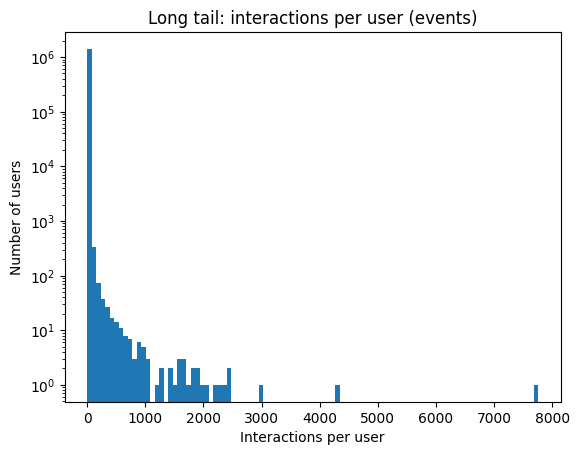

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) interactions per user = число событий на пользователя
user_counts = events.groupby("visitorid").size().astype("int32")

print("Interactions per user (events):")
print(user_counts.describe(percentiles=[.5,.75,.9,.95,.99,.999]))

plt.figure()
plt.hist(user_counts, bins=100)
plt.xlabel("Interactions per user")
plt.ylabel("Number of users")
plt.yscale("log")  # лог-шкала по Y помогает увидеть хвост
plt.title("Long tail: interactions per user (events)")
plt.show()

## (Опционально) long tail по уникальным товарам на пользователя

Unique items per user:
count    1.407580e+06
mean     1.524019e+00
std      7.143724e+00
min      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
90%      2.000000e+00
95%      3.000000e+00
99%      8.000000e+00
99.9%    2.600000e+01
max      3.814000e+03
Name: itemid, dtype: float64


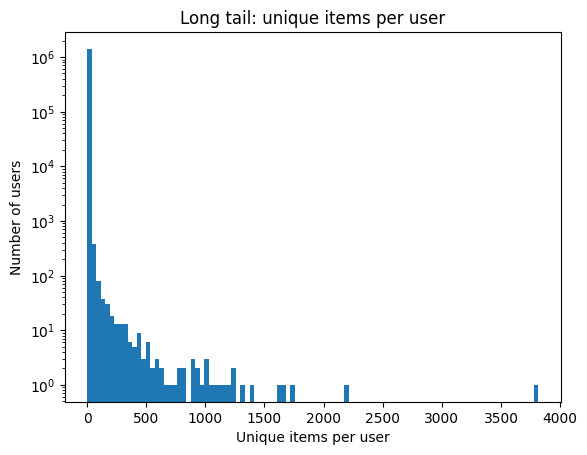

In [ ]:
user_unique_items = events.groupby("visitorid")["itemid"].nunique().astype("int32")

print("Unique items per user:")
print(user_unique_items.describe(percentiles=[.5,.75,.9,.95,.99,.999]))

plt.figure()
plt.hist(user_unique_items, bins=100)
plt.xlabel("Unique items per user")
plt.ylabel("Number of users")
plt.yscale("log")
plt.title("Long tail: unique items per user")
plt.show()

## 2) Interactions per item (popularity skew)

Interactions per item (events):
count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
50%           3.000000
75%           9.000000
90%          25.000000
95%          47.000000
99%         143.000000
99.9%       426.000000
max        3412.000000
dtype: float64


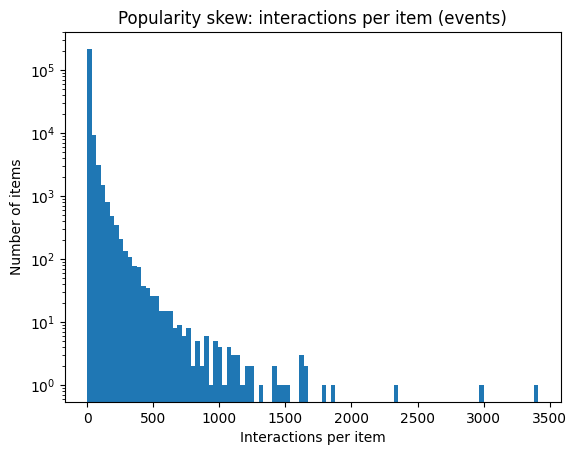

In [ ]:
# 2) interactions per item = число событий на товар
item_counts = events.groupby("itemid").size().astype("int32")

print("Interactions per item (events):")
print(item_counts.describe(percentiles=[.5,.75,.9,.95,.99,.999]))

plt.figure()
plt.hist(item_counts, bins=100)
plt.xlabel("Interactions per item")
plt.ylabel("Number of items")
plt.yscale("log")
plt.title("Popularity skew: interactions per item (events)")
plt.show()

## 3) Популярность: доля взаимодействий, приходящаяся на топ-K товаров (skew)

Это наглядно показывает, насколько “хвостатое” распределение (например, топ-1% товаров даёт X% всех событий).

In [ ]:
def top_share(counts: pd.Series, top_frac: float) -> float:
    counts_sorted = counts.sort_values(ascending=False).to_numpy()
    k = max(1, int(len(counts_sorted) * top_frac))
    return counts_sorted[:k].sum() / counts_sorted.sum()

for frac in [0.001, 0.01, 0.05, 0.10]:
    share = top_share(item_counts, frac)
    print(f"Top {frac*100:.1f}% items account for {share*100:.2f}% of all item interactions")

Top 0.1% items account for 6.11% of all item interactions
Top 1.0% items account for 22.95% of all item interactions
Top 5.0% items account for 49.32% of all item interactions
Top 10.0% items account for 64.03% of all item interactions


## Gini для item popularity (чем ближе к 1 — тем сильнее skew)

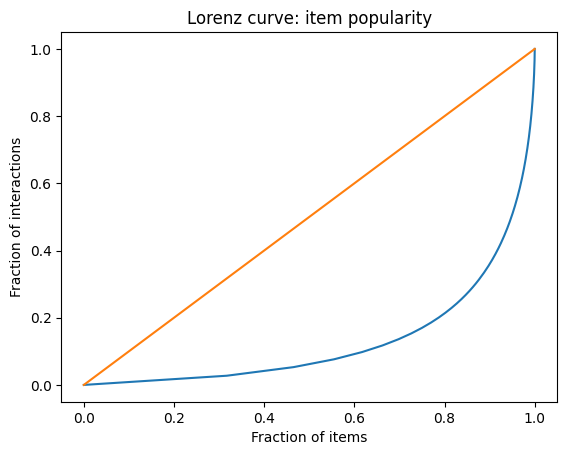

Gini (item popularity): 0.7394


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gini(x: np.ndarray) -> float:
    x = x.astype(np.float64)
    x = x[x >= 0]
    if x.size == 0:
        return np.nan
    x_sorted = np.sort(x)
    n = x_sorted.size
    cumx = np.cumsum(x_sorted)
    return (n + 1 - 2 * (cumx.sum() / cumx[-1])) / n

# Lorenz curve for item popularity
x = item_counts.to_numpy()
x_sorted = np.sort(x)
cum = np.cumsum(x_sorted) / x_sorted.sum()
p = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

plt.figure()
plt.plot(p, cum)
plt.plot([0,1], [0,1])
plt.xlabel("Fraction of items")
plt.ylabel("Fraction of interactions")
plt.title("Lorenz curve: item popularity")
plt.show()

print("Gini (item popularity):", round(gini(item_counts.to_numpy()), 4))

## Процент пользователей с 1 / 2 / 3 взаимодействиями

In [ ]:
import numpy as np
import pandas as pd

# количество событий на пользователя
user_counts = events.groupby("visitorid").size()

total_users = len(user_counts)

pct_1 = (user_counts == 1).sum() / total_users * 100
pct_2 = (user_counts == 2).sum() / total_users * 100
pct_3 = (user_counts == 3).sum() / total_users * 100

print("===== USER ACTIVITY DISTRIBUTION =====")
print(f"Users with exactly 1 interaction: {pct_1:.2f}%")
print(f"Users with exactly 2 interactions: {pct_2:.2f}%")
print(f"Users with exactly 3 interactions: {pct_3:.2f}%")
print(f"Users with <=3 interactions total: {((user_counts<=3).sum()/total_users*100):.2f}%")

===== USER ACTIVITY DISTRIBUTION =====
Users with exactly 1 interaction: 71.15%
Users with exactly 2 interactions: 14.63%
Users with exactly 3 interactions: 5.66%
Users with <=3 interactions total: 91.45%


## Доля событий, приходящаяся на топ-K% пользователей (user activity skew)

In [ ]:
def top_user_share(user_counts: pd.Series, top_frac: float) -> float:
    counts_sorted = user_counts.sort_values(ascending=False).to_numpy()
    k = max(1, int(len(counts_sorted) * top_frac))
    return counts_sorted[:k].sum() / counts_sorted.sum()

print("\n===== USER ACTIVITY SKEW =====")
for frac in [0.01, 0.05, 0.10]:
    share = top_user_share(user_counts, frac)
    print(f"Top {frac*100:.0f}% users account for {share*100:.2f}% of all interactions")


===== USER ACTIVITY SKEW =====
Top 1% users account for 17.52% of all interactions
Top 5% users account for 32.38% of all interactions
Top 10% users account for 42.26% of all interactions


## Состав событий (доли view/addtocart/transaction (дисбаланс)

===== EVENT COMPOSITION (IMBALANCE) =====


,count,share_%
event,,
view,2664312,96.67
addtocart,69332,2.52
transaction,22457,0.81


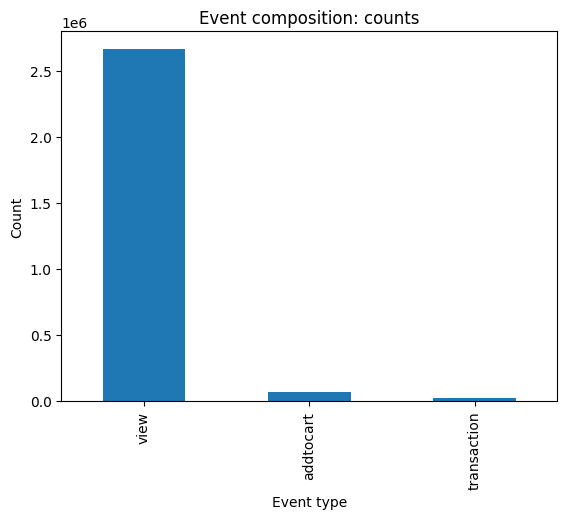

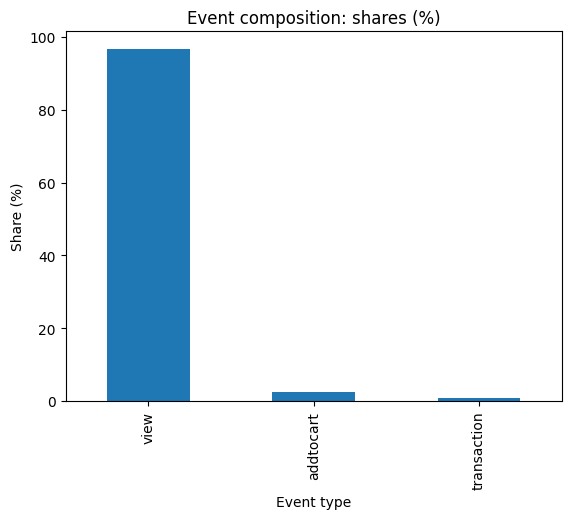

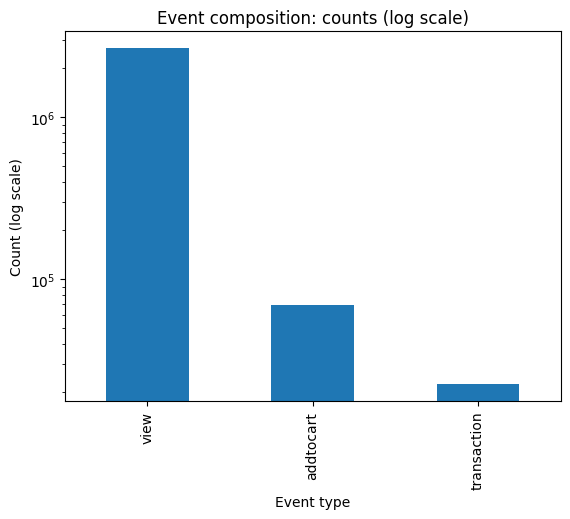

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Counts + shares
event_counts = events["event"].value_counts(dropna=False)
event_shares = (event_counts / event_counts.sum() * 100).round(2)

eda_events = pd.DataFrame({
    "count": event_counts,
    "share_%": event_shares
})

print("===== EVENT COMPOSITION (IMBALANCE) =====")
display(eda_events)

# 2) Bar chart (counts)
plt.figure()
event_counts.plot(kind="bar")
plt.xlabel("Event type")
plt.ylabel("Count")
plt.title("Event composition: counts")
plt.show()

# 3) Bar chart (shares, %)
plt.figure()
event_shares.plot(kind="bar")
plt.xlabel("Event type")
plt.ylabel("Share (%)")
plt.title("Event composition: shares (%)")
plt.show()

# 4) (Optional) Log-scale counts for better visibility
plt.figure()
event_counts.plot(kind="bar", logy=True)
plt.xlabel("Event type")
plt.ylabel("Count (log scale)")
plt.title("Event composition: counts (log scale)")
plt.show()

## EDA Временная динамика

*   события по дням/часам
*   длины сессий

Подготовка времени

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Переводим timestamp (мс) в datetime
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")

# Выделяем день и час
events["date"] = events["datetime"].dt.date
events["hour"] = events["datetime"].dt.hour

### События по дням

/tmp/ipykernel_569/1713744811.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["date", "event"])


<Figure size 640x480 with 0 Axes>

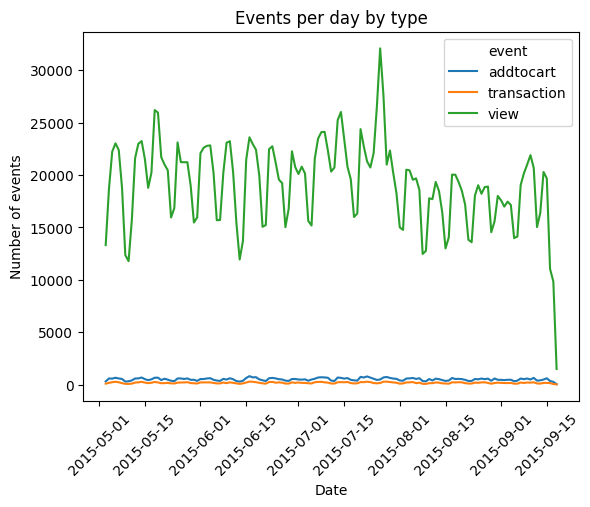

event,addtocart,transaction,view
date,,,
2015-09-14,475,154,20284
2015-09-15,595,158,19674
2015-09-16,336,137,11022
2015-09-17,253,45,9830
2015-09-18,34,15,1479


In [ ]:
# Группировка по дате и типу события
events_per_day_type = (
    events
    .groupby(["date", "event"])
    .size()
    .unstack(fill_value=0)
)

plt.figure()
events_per_day_type.plot()
plt.xlabel("Date")
plt.ylabel("Number of events")
plt.title("Events per day by type")
plt.xticks(rotation=45)
plt.show()

events_per_day_type.tail()

### События по часам суток

/tmp/ipykernel_569/88351199.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["hour", "event"])


<Figure size 640x480 with 0 Axes>

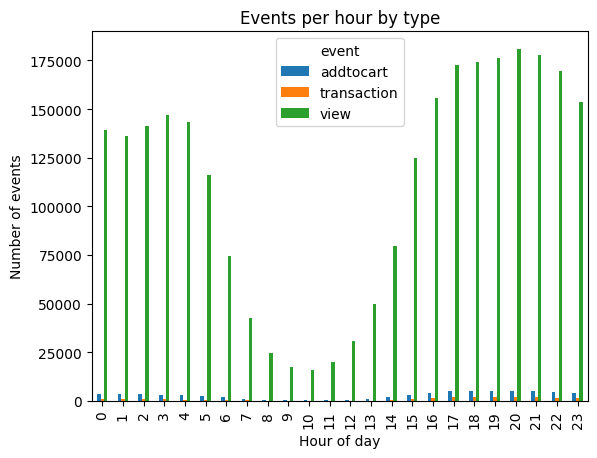

event,addtocart,transaction,view
hour,,,
0,3725,1119,139459
1,3578,1037,136087
2,3337,1012,141530
3,3266,836,146758
4,3141,747,143296
5,2786,747,116039
6,1803,477,74692
7,1028,278,42638
8,540,106,24663


In [ ]:
events_per_hour_type = (
    events
    .groupby(["hour", "event"])
    .size()
    .unstack(fill_value=0)
)

plt.figure()
events_per_hour_type.plot(kind="bar")
plt.xlabel("Hour of day")
plt.ylabel("Number of events")
plt.title("Events per hour by type")
plt.show()

events_per_hour_type

### Конверсия по часам (transaction / view)

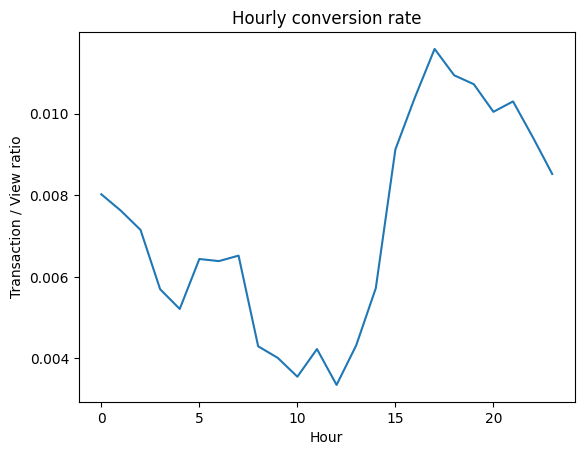

event,conversion_rate
hour,
0,0.008024
1,0.007620
2,0.007150
3,0.005696
4,0.005213
5,0.006437
6,0.006386
7,0.006520
8,0.004298


In [ ]:
hourly = events_per_hour_type.copy()

# Чтобы избежать деления на 0
hourly["conversion_rate"] = (
    hourly["transaction"] / hourly["view"].replace(0, np.nan)
)

plt.figure()
hourly["conversion_rate"].plot()
plt.xlabel("Hour")
plt.ylabel("Transaction / View ratio")
plt.title("Hourly conversion rate")
plt.show()

hourly[["conversion_rate"]]

## Длины сессий с раздельной аналитикой по типам

### Подготовка данных (минимальный набор колонок)

In [ ]:
# =========================
# 1. Подготовка данных
# =========================

import numpy as np
import pandas as pd

# Берём только нужные столбцы
df = events[["visitorid", "event", "timestamp"]].copy()

df["visitorid"] = df["visitorid"].astype("int32")
df["event"] = df["event"].astype("category")
df["ts_sec"] = (df["timestamp"] // 1000).astype("int64")

df.drop(columns=["timestamp"], inplace=True)

### Сортировка и построение сессий (30 минут разрыва)

In [ ]:
# =========================
# 2. Sessionization (gap = 30 min)
# =========================

df.sort_values(["visitorid", "ts_sec"], inplace=True, kind="mergesort")

SESSION_GAP_SEC = 30 * 60

u = df["visitorid"].to_numpy()
t = df["ts_sec"].to_numpy()

# разница во времени
dt = np.empty_like(t)
dt[0] = 0
dt[1:] = t[1:] - t[:-1]

# новая сессия если сменился пользователь или пауза > 30 мин
new_user = np.empty_like(u, dtype=bool)
new_user[0] = True
new_user[1:] = u[1:] != u[:-1]

new_session = new_user | (dt > SESSION_GAP_SEC)

# глобальный id сессии
df["session_gid"] = np.cumsum(new_session).astype("int32")

### Количество каждого типа событий в сессии

In [ ]:
# =========================
# 3. Количество событий каждого типа в сессии
# =========================

# Подсчёт событий по типам внутри каждой сессии
session_event_counts = pd.crosstab(df["session_gid"], df["event"])

# Общее количество событий в сессии
session_event_counts["total_events"] = session_event_counts.sum(axis=1)

print("===== EVENTS PER SESSION (BY TYPE) =====")
display(session_event_counts.head())


# =========================
# SUMMARY (без scientific notation)
# =========================

# Временно отключаем scientific notation
with pd.option_context('display.float_format', '{:,.6f}'.format):
    summary = session_event_counts.describe(
        percentiles=[.5, .75, .9, .95, .99]
    )

    print("\n===== SUMMARY =====")
    display(summary)

===== EVENTS PER SESSION (BY TYPE) =====


event,addtocart,transaction,view,total_events
session_gid,,,,
1,0,0,3,3
2,0,0,1,1
3,0,0,8,8
4,0,0,1,1
5,0,0,1,1



===== SUMMARY =====


event,addtocart,transaction,view,total_events
count,"1,761,660.000000","1,761,660.000000","1,761,660.000000","1,761,660.000000"
mean,0.039356,0.012748,1.512387,1.564491
std,0.399560,0.207125,2.352514,2.600096
min,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,1.000000
75%,0.000000,0.000000,1.000000,1.000000
90%,0.000000,0.000000,2.000000,2.000000
95%,0.000000,0.000000,4.000000,4.000000
99%,1.000000,0.000000,8.000000,9.000000
max,114.000000,59.000000,417.000000,417.000000


## EDA по категориям и свойствам

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("ecommerce_data")  # поменяй, если нужно

cat_path = DATA_DIR / "category_tree.csv"
ip1_path = DATA_DIR / "item_properties_part1.csv"
ip2_path = DATA_DIR / "item_properties_part2.csv"

# category_tree (заголовок может быть или не быть)
category_tree = pd.read_csv(cat_path)
if set(category_tree.columns) != {"categoryid", "parentid"}:
    category_tree = pd.read_csv(cat_path, header=None, names=["categoryid", "parentid"])

category_tree["categoryid"] = category_tree["categoryid"].astype("int32")
category_tree["parentid"] = pd.to_numeric(category_tree["parentid"], errors="coerce").astype("Int32")

# events должен быть уже загружен ранее
# events: timestamp, visitorid, event, itemid, transactionid
events["itemid"] = events["itemid"].astype("int32")
events["event"] = events["event"].astype("category")

### Глубина дерева категорий (max/avg + распределение)

===== CATEGORY TREE DEPTH =====
#categories: 1,669
max depth: 5
mean depth: 2.395
median depth: 2.000


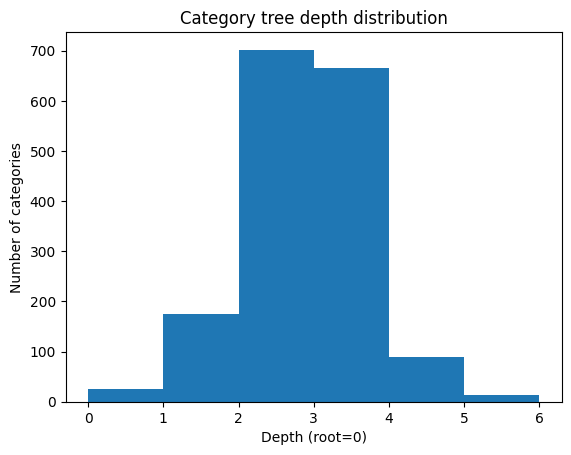

In [ ]:
# =========================
# 1. Depth of category tree
# =========================

# parent map (child -> parent)
parent = dict(zip(category_tree["categoryid"].tolist(),
                  category_tree["parentid"].fillna(-1).astype("int32").tolist()))

cats = category_tree["categoryid"].to_numpy()

# мемоизация глубины
depth_cache = {}

def depth_of(c):
    # depth(root)=0; depth(child)=depth(parent)+1
    if c in depth_cache:
        return depth_cache[c]
    seen = set()
    cur = c
    path = []
    while True:
        if cur in depth_cache:
            d0 = depth_cache[cur]
            # раскатываем назад
            for i, node in enumerate(reversed(path), start=1):
                depth_cache[node] = d0 + i
            return depth_cache[c]
        if cur in seen:
            # цикл (в норме не должно быть)
            for node in path:
                depth_cache[node] = np.nan
            depth_cache[c] = np.nan
            return np.nan
        seen.add(cur)
        path.append(cur)
        p = parent.get(cur, -1)
        if p is None or p == -1:
            # cur — корень
            depth_cache[cur] = 0
            # раскатываем назад
            for i, node in enumerate(reversed(path[:-1]), start=1):
                depth_cache[node] = i
            return depth_cache[c]
        cur = int(p)

depths = pd.Series({int(c): depth_of(int(c)) for c in cats}, name="depth").dropna()

print("===== CATEGORY TREE DEPTH =====")
print(f"#categories: {len(depths):,}")
print(f"max depth: {int(depths.max())}")
print(f"mean depth: {depths.mean():.3f}")
print(f"median depth: {depths.median():.3f}")

plt.figure()
plt.hist(depths, bins=range(0, int(depths.max()) + 2))
plt.xlabel("Depth (root=0)")
plt.ylabel("Number of categories")
plt.title("Category tree depth distribution")
plt.show()

### Извлечение item → category (memory-safe, только property == 'categoryid')

Мы берём последнюю известную категорию товара (по максимальному timestamp).

In [ ]:
# =========================
# 2. Build item -> category mapping (latest)
# =========================

def build_item_category_map(paths, chunksize=2_000_000):
    # itemid -> (latest_ts, categoryid)
    latest_ts = {}
    latest_cat = {}

    for path in paths:
        for chunk in pd.read_csv(
            path,
            header=0,  # в этом датасете обычно есть header
            usecols=["timestamp", "itemid", "property", "value"],
            dtype={"timestamp": "int64", "itemid": "int32", "property": "object", "value": "object"},
            chunksize=chunksize
        ):
            # фильтруем только categoryid
            chunk = chunk[chunk["property"] == "categoryid"]
            if chunk.empty:
                continue

            # value -> int (там categoryid не захэширован, но хранится как строка)
            chunk["categoryid"] = pd.to_numeric(chunk["value"], errors="coerce").astype("Int32")
            chunk = chunk.dropna(subset=["categoryid"])

            # оставляем по каждому itemid запись с максимальным timestamp в этом чанке
            chunk = chunk.sort_values(["itemid", "timestamp"])
            chunk_latest = chunk.groupby("itemid", as_index=False).tail(1)

            for row in chunk_latest.itertuples(index=False):
                ts = int(row.timestamp)
                item = int(row.itemid)
                cat = int(row.categoryid)

                old_ts = latest_ts.get(item)
                if (old_ts is None) or (ts > old_ts):
                    latest_ts[item] = ts
                    latest_cat[item] = cat

    # в dataframe
    item_cat = pd.DataFrame({
        "itemid": list(latest_cat.keys()),
        "categoryid": list(latest_cat.values())
    })
    item_cat["itemid"] = item_cat["itemid"].astype("int32")
    item_cat["categoryid"] = item_cat["categoryid"].astype("int32")
    return item_cat

item_cat = build_item_category_map([ip1_path, ip2_path])
print(f"item->category mapped items: {len(item_cat):,}")
item_cat.head()

item->category mapped items: 417,053


,itemid,categoryid
0,6,1091
1,11,414
2,26,1503
3,32,1173
4,35,1301


### Распределение товаров по категориям

===== ITEMS PER CATEGORY =====
count     1180.000000
mean       353.434746
std        997.459967
min          1.000000
50%         78.500000
75%        289.250000
90%        780.700000
95%       1556.100000
99%       3593.620000
max      17231.000000
dtype: float64


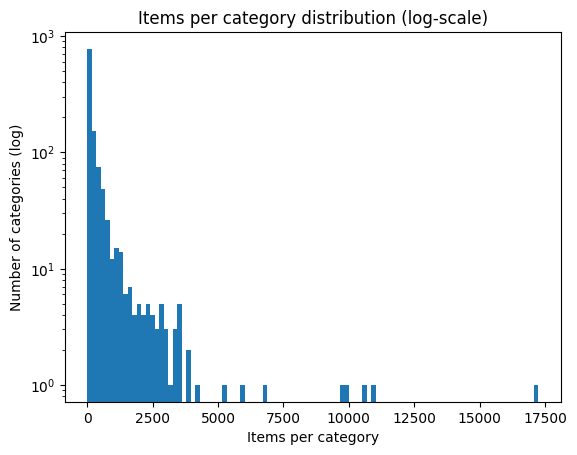

,items
categoryid,
342,17231
769,10982
173,10561
1301,9943
1007,9737
1142,6818
1680,6019
1250,5193
1070,4209


In [ ]:
# =========================
# 3. Items per category
# =========================

items_per_cat = item_cat.groupby("categoryid").size().sort_values(ascending=False)

print("===== ITEMS PER CATEGORY =====")
print(items_per_cat.describe(percentiles=[.5, .75, .9, .95, .99]))

plt.figure()
plt.hist(items_per_cat, bins=100)
plt.yscale("log")
plt.xlabel("Items per category")
plt.ylabel("Number of categories (log)")
plt.title("Items per category distribution (log-scale)")
plt.show()

# Top categories by #items
display(items_per_cat.head(10).to_frame("items"))

### Распределение событий по категориям

Сначала присоединяем категорию к событиям через itemid.

Category coverage in events (share of events with known category): 90.73%
===== EVENTS PER CATEGORY =====
count     1086.000000
mean      2302.500921
std       5639.037803
min          1.000000
50%        497.500000
75%       2206.500000
90%       5990.000000
95%       9974.750000
99%      25004.300000
max      75216.000000
dtype: float64


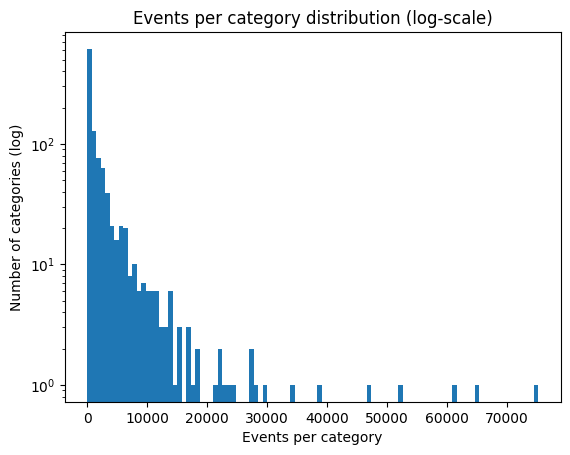

,events
categoryid,
1051.0,75216
1483.0,64780
491.0,61114
959.0,52278
342.0,46852
683.0,38887
1279.0,34381
5.0,29716
646.0,28240


In [ ]:
# =========================
# 4. Events per category
# =========================

events_cat = events.merge(item_cat, on="itemid", how="left")

coverage = events_cat["categoryid"].notna().mean() * 100
print(f"Category coverage in events (share of events with known category): {coverage:.2f}%")

events_per_cat = events_cat.dropna(subset=["categoryid"]).groupby("categoryid").size().sort_values(ascending=False)

print("===== EVENTS PER CATEGORY =====")
print(events_per_cat.describe(percentiles=[.5, .75, .9, .95, .99]))

plt.figure()
plt.hist(events_per_cat, bins=100)
plt.yscale("log")
plt.xlabel("Events per category")
plt.ylabel("Number of categories (log)")
plt.title("Events per category distribution (log-scale)")
plt.show()

display(events_per_cat.head(10).to_frame("events"))

### Конверсия по категориям (transaction / view)

In [ ]:
# =========================
# 5. Conversion rate per category
# =========================

pivot = (
    events_cat.dropna(subset=["categoryid"])
    .groupby(["categoryid", "event"])
    .size()
    .unstack(fill_value=0)
)

# гарантируем колонки
for col in ["view", "addtocart", "transaction"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot["conversion_tx_view"] = pivot["transaction"] / pivot["view"].replace(0, np.nan)
pivot["cart_rate_cart_view"] = pivot["addtocart"] / pivot["view"].replace(0, np.nan)

# часто фильтруют категории с малым числом просмотров, чтобы конверсия не была шумной
MIN_VIEWS = 1000
pivot_f = pivot[pivot["view"] >= MIN_VIEWS].copy()

print(f"Categories with >= {MIN_VIEWS} views: {len(pivot_f):,}")

top_conv = pivot_f.sort_values("conversion_tx_view", ascending=False).head(15)
display(top_conv[["view", "addtocart", "transaction", "conversion_tx_view", "cart_rate_cart_view"]])

Categories with >= 1000 views: 410


/tmp/ipykernel_569/627874723.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["categoryid", "event"])


event,view,addtocart,transaction,conversion_tx_view,cart_rate_cart_view
categoryid,,,,,
57.0,2229,128,150,0.067295,0.057425
1037.0,5190,658,226,0.043545,0.126782
417.0,1916,206,82,0.042797,0.107516
686.0,6052,426,236,0.038995,0.070390
972.0,1975,164,74,0.037468,0.083038
1493.0,4277,448,155,0.036240,0.104746
1163.0,7157,374,259,0.036188,0.052257
1043.0,1893,67,63,0.033281,0.035394
1286.0,1736,285,57,0.032834,0.164171


## Gini по популярности категорий

Считаем Gini для распределения “популярности”:

*   по events (все события)
*   по views (только просмотры)

In [ ]:
# =========================
# 6. Gini for category popularity
# =========================

def gini(x: np.ndarray) -> float:
    x = x.astype(np.float64)
    x = x[x >= 0]
    if x.size == 0:
        return np.nan
    x_sorted = np.sort(x)
    n = x_sorted.size
    cumx = np.cumsum(x_sorted)
    return (n + 1 - 2 * (cumx.sum() / cumx[-1])) / n

# popularity by all events
gini_events = gini(events_per_cat.to_numpy())

# popularity by views only
views_per_cat = (
    events_cat.dropna(subset=["categoryid"])
    .query("event == 'view'")
    .groupby("categoryid")
    .size()
)
gini_views = gini(views_per_cat.to_numpy())

print("===== GINI (CATEGORY POPULARITY) =====")
print(f"Gini by all events: {gini_events:.4f}")
print(f"Gini by views only: {gini_views:.4f}")

===== GINI (CATEGORY POPULARITY) =====
Gini by all events: 0.7630
Gini by views only: 0.7634


# Подготовка и очистка данных

## Удаление дубликатов

Проверим наличие дубликатов

In [ ]:
print("Total rows before:", len(events))

full_duplicates = events.duplicated().sum()
print("Full duplicate rows:", full_duplicates)

Total rows before: 2756101
Full duplicate rows: 460


Удаление полных дубликатов

In [ ]:
events = events.drop_duplicates()

print("Total rows after removing full duplicates:", len(events))

Total rows after removing full duplicates: 2755641


Проверка логических дублей (по ключевым полям)

Иногда строка может отличаться transactionid, но быть логически одинаковой.

Для implicit-сценария логический ключ:



*   visitorid
*   itemid


*   event
*   timestamp

In [ ]:
logical_duplicates = events.duplicated(
    subset=["visitorid", "itemid", "event", "timestamp"]
).sum()

print("Logical duplicates:", logical_duplicates)

Logical duplicates: 0


Если > 0 — удаляем:

In [ ]:
events = events.drop_duplicates(
    subset=["visitorid", "itemid", "event", "timestamp"]
)

print("Rows after logical deduplication:", len(events))

Rows after logical deduplication: 2755641


Контрольная проверка

In [ ]:
print("Remaining full duplicates:", events.duplicated().sum())

Remaining full duplicates: 0


## Проверка типов данных и пропусков

In [ ]:
print("===== DATA TYPES =====")
print(events.dtypes)

===== DATA TYPES =====
timestamp                 int64
visitorid                 int32
event                  category
itemid                    int32
transactionid             int32
datetime         datetime64[ns]
date                     object
hour                      int32
dtype: object


Приведение типов к корректным

In [ ]:
# timestamp -> int64
events["timestamp"] = events["timestamp"].astype("int64")

# visitorid и itemid -> int32 (экономим память)
events["visitorid"] = events["visitorid"].astype("int32")
events["itemid"] = events["itemid"].astype("int32")

# event -> category
events["event"] = events["event"].astype("category")

# transactionid может быть NaN -> сначала float, потом заполнить
if "transactionid" in events.columns:
    events["transactionid"] = (
        pd.to_numeric(events["transactionid"], errors="coerce")
        .fillna(-1)
        .astype("int32")
    )

print("===== DATA TYPES AFTER FIX =====")
print(events.dtypes)

===== DATA TYPES AFTER FIX =====
timestamp                 int64
visitorid                 int32
event                  category
itemid                    int32
transactionid             int32
datetime         datetime64[ns]
date                     object
hour                      int32
dtype: object


Проверка пропусков

In [ ]:
print("===== MISSING VALUES =====")
print(events.isna().sum())

===== MISSING VALUES =====
timestamp        0
visitorid        0
event            0
itemid           0
transactionid    0
datetime         0
date             0
hour             0
dtype: int64


Проверка логически невозможных значений

In [ ]:
print("Negative visitorid:", (events["visitorid"] < 0).sum())
print("Negative itemid:", (events["itemid"] < 0).sum())

Negative visitorid: 0
Negative itemid: 0


Проверка уникальных типов событий

In [ ]:
print("===== UNIQUE EVENT TYPES =====")
print(events["event"].value_counts())

===== UNIQUE EVENT TYPES =====
event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64


## Очистка пользователей и товаров



*   Удаляем «слабых» пользователей (<3 взаимодействий)
*   Удаляем редкие товары (<5 взаимодействий)
*   Убираем экстремально активных пользователей







In [ ]:
print("===== BEFORE FILTERING =====")
print("Rows:", len(events))
print("Users:", events["visitorid"].nunique())
print("Items:", events["itemid"].nunique())

===== BEFORE FILTERING =====
Rows: 2755641
Users: 1407580
Items: 235061


### Удаление ботов

In [ ]:
user_counts = events["visitorid"].value_counts()

threshold = user_counts.quantile(0.999)

events = events[
    events["visitorid"].isin(
        user_counts[user_counts <= threshold].index
    )
].copy()

print("After bot removal:")
print("Max interactions per user:", events["visitorid"].value_counts().max())

After bot removal:
Max interactions per user: 47


### Удаление "слабых" пользователей и редких товаров

In [ ]:
MIN_USER_INTERACTIONS = 3
MIN_ITEM_INTERACTIONS = 5

changed = True

while changed:
    before_rows = len(events)

    # фильтрация пользователей
    user_counts = events["visitorid"].value_counts()
    valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
    events = events[events["visitorid"].isin(valid_users)]

    # фильтрация товаров
    item_counts = events["itemid"].value_counts()
    valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index
    events = events[events["itemid"].isin(valid_items)]

    after_rows = len(events)
    changed = before_rows != after_rows

print("===== AFTER ITERATIVE FILTERING =====")
print("Rows:", len(events))
print("Users:", events["visitorid"].nunique())
print("Items:", events["itemid"].nunique())

===== AFTER ITERATIVE FILTERING =====
Rows: 917970
Users: 159906
Items: 41806


In [ ]:
print("\n===== FINAL CHECK =====")
print("Min interactions per user:", events["visitorid"].value_counts().min())
print("Min interactions per item:", events["itemid"].value_counts().min())


===== FINAL CHECK =====
Min interactions per user: 3
Min interactions per item: 5


In [ ]:
import numpy as np
import pandas as pd

# Основные размеры
num_events = len(events)                       # |E|_events
num_users  = events["visitorid"].nunique()    # N
num_items  = events["itemid"].nunique()       # D

# |E| = уникальные user-item пары
E_unique_pairs = events.drop_duplicates(
    subset=["visitorid", "itemid"]
).shape[0]

# |E| = число событий (каждая строка)
E_events = num_events

# Density и sparsity (variant A: unique pairs)
density_unique = E_unique_pairs / (num_users * num_items)
sparsity_unique = 1 - density_unique

# Density и sparsity (variant B: raw events)
density_events = E_events / (num_users * num_items)
sparsity_events = 1 - density_events

print("===== DATASET STATISTICS =====")
print(f"#events (rows in events.csv): {num_events:,}")
print(f"#users (N): {num_users:,}")
print(f"#items (D): {num_items:,}")
print()
print(f"|E| (unique user-item pairs): {E_unique_pairs:,}")
print(f"|E| (all events): {E_events:,}")
print()

print("===== DENSITY & SPARSITY =====")
print("Using unique user-item pairs:")
print(f"density = {density_unique:.10f}")
print(f"sparsity = {sparsity_unique:.6f}")
print()

print("Using all events:")
print(f"density = {density_events:.10f}")
print(f"sparsity = {sparsity_events:.6f}")
print()

print("===== EVENT DISTRIBUTION =====")
print(events["event"].value_counts())

===== DATASET STATISTICS =====
#events (rows in events.csv): 917,970
#users (N): 159,906
#items (D): 41,806

|E| (unique user-item pairs): 534,710
|E| (all events): 917,970

===== DENSITY & SPARSITY =====
Using unique user-item pairs:
density = 0.0000799862
sparsity = 0.999920

Using all events:
density = 0.0001373173
sparsity = 0.999863

===== EVENT DISTRIBUTION =====
event
view           862279
addtocart       41977
transaction     13714
Name: count, dtype: int64


## Формирование взвешенного implicit feedback

In [ ]:
# =========================
# WEIGHTED IMPLICIT FEEDBACK
# =========================

# задаём веса
weights = {
    "view": 1,
    "addtocart": 3,
    "transaction": 5
}

events["weight"] = events["event"].map(weights).astype("int32")

print("===== CHECK WEIGHTS =====")
print(events.groupby("event", observed=False)["weight"].mean())

===== CHECK WEIGHTS =====
event
addtocart      3.0
transaction    5.0
view           1.0
Name: weight, dtype: float64


In [ ]:
print("\n===== WEIGHT DISTRIBUTION =====")
print(events["weight"].value_counts())


===== WEIGHT DISTRIBUTION =====
weight
1    862279
3     41977
5     13714
Name: count, dtype: int64


## ### Агрегация по user-item + Временная сортировка для leave-last-out

In [ ]:
# агрегируем веса по user-item + последнее время
interactions = (
    events
    .groupby(["visitorid", "itemid"], as_index=False)
    .agg(
        weight=("weight", "sum"),
        last_ts=("timestamp", "max")
    )
)

# фильтрация пользователей для leave-last-out (на уровне interactions!)
MIN_USER_INTERACTIONS_AGG = 3
u_cnt = interactions["visitorid"].value_counts()
valid_users = u_cnt[u_cnt >= MIN_USER_INTERACTIONS_AGG].index
interactions = interactions[interactions["visitorid"].isin(valid_users)].copy()

print("Users after AGG filtering:", interactions["visitorid"].nunique())
print("Min interactions per user (AGG):", interactions["visitorid"].value_counts().min())

Users after AGG filtering: 87641
Min interactions per user (AGG): 3


## Leave-Last-Out Split

In [ ]:
# =========================
# LEAVE-LAST-OUT SPLIT
# =========================

# считаем количество взаимодействий на пользователя
user_inter_counts = interactions["visitorid"].value_counts()

# проверка: у всех должно быть >=3
print("Min interactions per user:", user_inter_counts.min())

# добавим порядковый номер взаимодействия внутри пользователя
interactions["rank"] = (
    interactions
    .groupby("visitorid")["last_ts"]
    .rank(method="first")
)

# максимальный ранг для каждого пользователя
interactions["max_rank"] = (
    interactions
    .groupby("visitorid")["rank"]
    .transform("max")
)

# формируем split
train = interactions[interactions["rank"] <= interactions["max_rank"] - 2].copy()
val   = interactions[interactions["rank"] == interactions["max_rank"] - 1].copy()
test  = interactions[interactions["rank"] == interactions["max_rank"]].copy()

print("===== SPLIT RESULT =====")
print("Train:", train.shape)
print("Valid:", val.shape)
print("Test :", test.shape)

Min interactions per user: 3
===== SPLIT RESULT =====
Train: (245572, 6)
Valid: (87641, 6)
Test : (87641, 6)


### Контроль корректности

In [ ]:
print("\n===== SANITY CHECK =====")

print("Users in train:", train["visitorid"].nunique())
print("Users in val  :", val["visitorid"].nunique())
print("Users in test :", test["visitorid"].nunique())

# у каждого пользователя должно быть ровно 1 запись в val и test
print("\nVal per user min/max:",
      val["visitorid"].value_counts().min(),
      val["visitorid"].value_counts().max())

print("Test per user min/max:",
      test["visitorid"].value_counts().min(),
      test["visitorid"].value_counts().max())


===== SANITY CHECK =====
Users in train: 87641
Users in val  : 87641
Users in test : 87641

Val per user min/max: 1 1
Test per user min/max: 1 1


### Удалить служебные столбцы rank, max_rank

In [ ]:
train = train.drop(columns=["rank", "max_rank"])
val   = val.drop(columns=["rank", "max_rank"])
test  = test.drop(columns=["rank", "max_rank"])

## Кодирование индексов по train

### Создание маппингов по train

In [ ]:
# =========================
# ENCODING BASED ON TRAIN
# =========================

# уникальные пользователи и товары в train
train_users = train["visitorid"].unique()
train_items = train["itemid"].unique()

# создаём словари
user2idx = {u: i for i, u in enumerate(train_users)}
item2idx = {it: i for i, it in enumerate(train_items)}

print("Users in mapping:", len(user2idx))
print("Items in mapping:", len(item2idx))

Users in mapping: 87641
Items in mapping: 36048


### Применение к train

In [ ]:
train["user_idx"] = train["visitorid"].map(user2idx)
train["item_idx"] = train["itemid"].map(item2idx)

print("Train shape after encoding:", train.shape)

Train shape after encoding: (245572, 6)


### Применение к val и test

In [ ]:
val["user_idx"] = val["visitorid"].map(user2idx)
val["item_idx"] = val["itemid"].map(item2idx)

test["user_idx"] = test["visitorid"].map(user2idx)
test["item_idx"] = test["itemid"].map(item2idx)

### Проверка на cold-start

In [ ]:
print("Unknown users in val:", val["user_idx"].isna().sum())
print("Unknown items in val:", val["item_idx"].isna().sum())

print("Unknown users in test:", test["user_idx"].isna().sum())
print("Unknown items in test:", test["item_idx"].isna().sum())

Unknown users in val: 0
Unknown items in val: 2612
Unknown users in test: 0
Unknown items in test: 3299


### Удаление неизвестных

In [ ]:
val = val.dropna(subset=["user_idx", "item_idx"]).copy()
test = test.dropna(subset=["user_idx", "item_idx"]).copy()

# приводим к int
train[["user_idx", "item_idx"]] = train[["user_idx", "item_idx"]].astype("int32")
val[["user_idx", "item_idx"]]   = val[["user_idx", "item_idx"]].astype("int32")
test[["user_idx", "item_idx"]]  = test[["user_idx", "item_idx"]].astype("int32")

In [ ]:
print("Unknown users in val:", val["user_idx"].isna().sum())
print("Unknown items in val:", val["item_idx"].isna().sum())

print("Unknown users in test:", test["user_idx"].isna().sum())
print("Unknown items in test:", test["item_idx"].isna().sum())

Unknown users in val: 0
Unknown items in val: 0
Unknown users in test: 0
Unknown items in test: 0


### Контроль финальных размеров

In [ ]:
print("===== FINAL SPLIT =====")
print("Train:", train.shape)
print("Val  :", val.shape)
print("Test :", test.shape)

print("Users:", train["user_idx"].nunique())
print("Items:", train["item_idx"].nunique())

===== FINAL SPLIT =====
Train: (245572, 6)
Val  : (85029, 6)
Test : (84342, 6)
Users: 87641
Items: 36048


## sparse-матрицы

### Размеры матрицы

In [ ]:
n_users = train["user_idx"].nunique()
n_items = train["item_idx"].nunique()

print("Users:", n_users)
print("Items:", n_items)

Users: 87641
Items: 36048


### Weighted sparse matrix (ALS, Autoencoder)

In [ ]:
from scipy.sparse import csr_matrix

R_train_weighted = csr_matrix(
    (
        train["weight"],
        (train["user_idx"], train["item_idx"])
    ),
    shape=(n_users, n_items)
)

print("Weighted matrix shape:", R_train_weighted.shape)
print("Non-zero entries:", R_train_weighted.nnz)

Weighted matrix shape: (87641, 36048)
Non-zero entries: 245572


### Binary sparse matrix (BPR, UserCF, ItemCF)

In [ ]:
import numpy as np

R_train_binary = csr_matrix(
    (
        np.ones(len(train)),
        (train["user_idx"], train["item_idx"])
    ),
    shape=(n_users, n_items)
)

print("Binary matrix shape:", R_train_binary.shape)
print("Non-zero entries:", R_train_binary.nnz)

Binary matrix shape: (87641, 36048)
Non-zero entries: 245572


### Ground-truth для валидации и теста
Для Recall@K / NDCG@K нужно:

*   для каждого пользователя знать целевой item

In [ ]:
val_truth = val.groupby("user_idx")["item_idx"].apply(set).to_dict()
test_truth = test.groupby("user_idx")["item_idx"].apply(set).to_dict()

print("Users in val truth:", len(val_truth))
print("Users in test truth:", len(test_truth))

Users in val truth: 85029
Users in test truth: 84342


### Матрица seen items (для исключения из рекомендаций)

In [ ]:
train_seen = train.groupby("user_idx")["item_idx"].apply(set).to_dict()

### Проверка плотности train-матрицы

In [ ]:
density_train = R_train_binary.nnz / (n_users * n_items)
print("Train density:", density_train)

Train density: 7.773030084149783e-05


# Реализация метрик

In [ ]:
import numpy as np

# =========================
# Recall@K
# =========================
def recall_at_k(recommended, ground_truth, k):
    """
    recommended: list of ranked item_idx
    ground_truth: set of relevant item_idx
    """
    if not ground_truth:
        return 0.0

    recommended_k = recommended[:k]
    hits = sum(1 for item in recommended_k if item in ground_truth)

    return hits / len(ground_truth)


# =========================
# NDCG@K
# =========================
def ndcg_at_k(recommended, ground_truth, k):
    if not ground_truth:
        return 0.0

    recommended_k = recommended[:k]

    dcg = 0.0
    for i, item in enumerate(recommended_k):
        if item in ground_truth:
            dcg += 1.0 / np.log2(i + 2)

    # ideal DCG
    ideal_hits = min(len(ground_truth), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0


# =========================
# Общая функция оценки
# =========================
def evaluate_model(recs, truth, k_list=(5, 10, 20)):
    results = {}
    users = list(truth.keys())

    for k in k_list:
        recall_scores = []
        ndcg_scores = []

        for u in users:
            recommended = recs.get(u, [])
            ground_truth = truth[u]

            recall_scores.append(recall_at_k(recommended, ground_truth, k))
            ndcg_scores.append(ndcg_at_k(recommended, ground_truth, k))

        results[f"Recall@{k}"] = np.mean(recall_scores)
        results[f"NDCG@{k}"] = np.mean(ndcg_scores)

    return results

# Popularity baseline

## Popularity baseline: Конфигурация + подготовка train_seen

In [ ]:
import numpy as np
import pandas as pd

# -------------------------
# 0) CONFIG
# -------------------------
CFG_POP = {
    "TOPN_RECS": 20,              # сколько рекомендаций строим
    "K_LIST": (5, 10, 20),        # какие K считаем в метриках
    "MODES": ("count", "weight")  # варианты popularity
}

# -------------------------
# 1) PREP: seen items (exclude from recs)
# -------------------------
# train_seen нужен для исключения уже увиденных товаров из рекомендаций
train_seen = train.groupby("user_idx")["item_idx"].apply(set).to_dict()

## Popularity baseline: обучение на train + генерация рекомендаций

In [ ]:
def build_popularity_ranking(train_df: pd.DataFrame, mode: str = "count") -> np.ndarray:
    """
    mode:
      - "count": популярность = число взаимодействий (после агрегации user-item это фактически "сколько пользователей")
      - "weight": популярность = сумма weight по item
    Returns: np.array of item_idx sorted by popularity desc
    """
    if mode == "count":
        pop = train_df.groupby("item_idx").size()
    elif mode == "weight":
        pop = train_df.groupby("item_idx")["weight"].sum()
    else:
        raise ValueError("mode must be 'count' or 'weight'")

    pop = pop.sort_values(ascending=False)
    return pop.index.to_numpy()

def recommend_popularity(pop_items_sorted: np.ndarray,
                         users,
                         seen_dict: dict,
                         topn: int = 20) -> dict:
    """
    pop_items_sorted: item_idx sorted by popularity desc
    users: iterable of user_idx
    seen_dict: user_idx -> set(item_idx) for filtering
    """
    recs = {}
    for u in users:
        u = int(u)
        seen = seen_dict.get(u, set())
        out = []
        for it in pop_items_sorted:
            it = int(it)
            if it not in seen:
                out.append(it)
                if len(out) == topn:
                    break
        recs[u] = out
    return recs

def run_popularity(train_df: pd.DataFrame,
                   val_truth: dict,
                   test_truth: dict,
                   seen_dict: dict,
                   cfg: dict = CFG_POP) -> dict:
    """
    Runs popularity for all modes; returns dict with metrics.
    """
    results = {}

    val_users = list(val_truth.keys())
    test_users = list(test_truth.keys())

    for mode in cfg["MODES"]:
        pop_items = build_popularity_ranking(train_df, mode=mode)

        recs_val  = recommend_popularity(pop_items, val_users,  seen_dict, topn=cfg["TOPN_RECS"])
        recs_test = recommend_popularity(pop_items, test_users, seen_dict, topn=cfg["TOPN_RECS"])

        results[f"pop_{mode}_val"]  = evaluate_model(recs_val,  val_truth,  k_list=cfg["K_LIST"])
        results[f"pop_{mode}_test"] = evaluate_model(recs_test, test_truth, k_list=cfg["K_LIST"])

    return results

##  Popularity baseline: рекомендации и оценка на val/test

In [ ]:
# -------------------------
# 3) RUN + save outputs for final table
# -------------------------
pop_results = run_popularity(train, val_truth, test_truth, train_seen, cfg=CFG_POP)

print("Popularity COUNT (VAL):",  pop_results["pop_count_val"])
print("Popularity COUNT (TEST):", pop_results["pop_count_test"])
print("Popularity WEIGHT (VAL):", pop_results["pop_weight_val"])
print("Popularity WEIGHT (TEST):", pop_results["pop_weight_test"])

# -------------------------
# 4) Save metrics into standard variables (for final results table)
# -------------------------
pop_count_val   = pop_results["pop_count_val"]
pop_count_test  = pop_results["pop_count_test"]
pop_weight_val  = pop_results["pop_weight_val"]
pop_weight_test = pop_results["pop_weight_test"]



Popularity COUNT (VAL): {'Recall@5': np.float64(0.0048571663785296785), 'NDCG@5': np.float64(0.0030185230902885353), 'Recall@10': np.float64(0.008632348963294876), 'NDCG@10': np.float64(0.004252539932184758), 'Recall@20': np.float64(0.013771771983676158), 'NDCG@20': np.float64(0.0055425270487838695)}
Popularity COUNT (TEST): {'Recall@5': np.float64(0.004386900950890422), 'NDCG@5': np.float64(0.0026714833215859594), 'Recall@10': np.float64(0.008560385098764554), 'NDCG@10': np.float64(0.00404719075157198), 'Recall@20': np.float64(0.013445258590026321), 'NDCG@20': np.float64(0.005273252468493175)}
Popularity WEIGHT (VAL): {'Recall@5': np.float64(0.003928071599101483), 'NDCG@5': np.float64(0.002502220628161381), 'Recall@10': np.float64(0.007879664585023934), 'NDCG@10': np.float64(0.0037570788567771415), 'Recall@20': np.float64(0.01344247256818262), 'NDCG@20': np.float64(0.005141636250036622)}
Popularity WEIGHT (TEST): {'Recall@5': np.float64(0.003983780322970762), 'NDCG@5': np.float64(0.00

# Функция сохранения на диск

In [ ]:
import os
import json
from datetime import datetime
import pandas as pd

# --- 0) Mount Google Drive (один раз в начале ноутбука) ---
from google.colab import drive
drive.mount('/content/drive')

# --- 1) Конфиг путей ---
DATASET_TAG = "RetailRocket_kcore_u3_i5_leave_last_out"   # поменяй как хочешь
BASE_DIR = "/content/drive/MyDrive/teachbox_recsys_results"
PROJECT_DIR = os.path.join(BASE_DIR, DATASET_TAG, "runs")

def make_run_id():
    # локальное время коллаба — обычно UTC; если важно, можешь вручную добавить TZ
    return datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

RUN_ID = make_run_id()
RUN_DIR = os.path.join(PROJECT_DIR, RUN_ID)
os.makedirs(RUN_DIR, exist_ok=True)

RESULTS_CSV_PATH = os.path.join(RUN_DIR, "results.csv")  # сводка внутри RUN
# Если хочешь "общую" сводку на все запуски — сделай путь выше, вне RUN_DIR.

print("RUN_DIR:", RUN_DIR)


# --- 2) Унификация: приводим словарь метрик к "плоской" строке таблицы ---
def flatten_metrics(algo_name: str, variant: str, metrics_dict: dict, extra: dict | None = None) -> dict:
    """
    algo_name: 'popularity', 'als', ...
    variant:   'count_val', 'weight_test', или что-то твоё (главное — стабильно)
    metrics_dict: например {'recall@20':0.12, 'ndcg@20':0.08, ...}
    extra: любые доп. поля: factors, iterations, k, alpha, etc.
    """
    row = {"algo": algo_name, "variant": variant}
    row.update(metrics_dict)
    if extra:
        row.update(extra)
    return row


# --- 3) Сохранение: JSON на диск + обновление results.csv ---
def save_algo_metrics(algo_name: str, payload: dict, run_dir: str = RUN_DIR):
    """
    payload — исходный словарь результатов (как pop_results), сохраняем как есть.
    """
    path = os.path.join(run_dir, f"{algo_name}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)
    return path

def upsert_results_table(rows: list[dict], results_csv_path: str = RESULTS_CSV_PATH):
    """
    rows: список строк-словарей для таблицы (обычно 2-4 строки на алгоритм: val/test, count/weight...)
    Логика: если results.csv существует — загружаем, добавляем новые строки, дедуп по (algo, variant).
    """
    new_df = pd.DataFrame(rows)

    if os.path.exists(results_csv_path):
        old_df = pd.read_csv(results_csv_path)
        combined = pd.concat([old_df, new_df], ignore_index=True)
        combined = combined.drop_duplicates(subset=["algo", "variant"], keep="last")
    else:
        combined = new_df

    combined = combined.sort_values(["algo", "variant"]).reset_index(drop=True)
    combined.to_csv(results_csv_path, index=False)
    return combined

def load_results_table(results_csv_path: str = RESULTS_CSV_PATH) -> pd.DataFrame:
    if not os.path.exists(results_csv_path):
        return pd.DataFrame()
    return pd.read_csv(results_csv_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUN_DIR: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57


In [ ]:
# -------------------------
# 5) SAVE to Google Drive (JSON + update results.csv)
# -------------------------
# 5.1 сохраняем "сырые" результаты в JSON (всё, что вернула функция)
json_path = save_algo_metrics("popularity", pop_results)
print("Saved popularity JSON:", json_path)

# 5.2 добавляем строки в сводную таблицу
rows = [
    flatten_metrics("popularity", "count_val",   pop_count_val),
    flatten_metrics("popularity", "count_test",  pop_count_test),
    flatten_metrics("popularity", "weight_val",  pop_weight_val),
    flatten_metrics("popularity", "weight_test", pop_weight_test),
]

summary_df = upsert_results_table(rows)
print("Updated results.csv:", RESULTS_CSV_PATH)
display(summary_df.tail(20))

Saved popularity JSON: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/popularity.json
Updated results.csv: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/results.csv


,algo,variant,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20
0,popularity,count_test,0.004387,0.002671,0.008560,0.004047,0.013445,0.005273
1,popularity,count_val,0.004857,0.003019,0.008632,0.004253,0.013772,0.005543
2,popularity,weight_test,0.003984,0.002723,0.007790,0.003918,0.013220,0.005267
3,popularity,weight_val,0.003928,0.002502,0.007880,0.003757,0.013442,0.005142


## ItemCF

## ItemCF: Конфигурация

In [ ]:
# =========================
# ItemCF (Item-based Collaborative Filtering) — Binary matrix
# =========================

import numpy as np
from collections import defaultdict
from scipy.sparse import csr_matrix, csc_matrix, diags

# -------------------------
# 0) CONFIG
# -------------------------
CFG_ITEMCF = {
    "TOPK_SIM": 100,          # сколько соседей оставляем на item (top-K similarity)
    "TOPN_RECS": 20,          # сколько рекомендаций выдаём пользователю
    "K_LIST": (5, 10, 20),    # K для Recall/NDCG
    "MIN_SCORE": 0.0          # порог по similarity (обычно 0.0)
}

# -------------------------
# 1) PREP: train_seen (exclude from recs)
# -------------------------
# если train_seen уже построен ранее — можно эту строку не выполнять повторно
train_seen = train.groupby("user_idx")["item_idx"].apply(set).to_dict()

## ItemCF: обучение (topK cosine neighbors)

In [ ]:
# -------------------------
# 2) Internal helpers
# -------------------------
def _l2_normalize_columns(X_csc: csc_matrix, eps: float = 1e-12) -> csc_matrix:
    """L2-нормализация столбцов sparse-матрицы (CSC)."""
    col_norms = np.sqrt(X_csc.power(2).sum(axis=0)).A1
    col_norms = np.maximum(col_norms, eps)
    inv = 1.0 / col_norms
    return X_csc @ diags(inv, offsets=0, format="csc")

def _topk_per_row_csr(A: csr_matrix, topk: int) -> csr_matrix:
    """Оставляет topk элементов в каждой строке CSR по значениям."""
    A = A.tocsr()
    A.sort_indices()

    indptr, indices, data = A.indptr, A.indices, A.data

    new_indptr = np.zeros_like(indptr)
    new_indices = []
    new_data = []

    nnz_so_far = 0
    new_indptr[0] = 0

    for r in range(A.shape[0]):
        start, end = indptr[r], indptr[r + 1]
        row_idx = indices[start:end]
        row_dat = data[start:end]

        if row_dat.size == 0:
            new_indptr[r + 1] = nnz_so_far
            continue

        if row_dat.size > topk:
            top_pos = np.argpartition(row_dat, -topk)[-topk:]
            top_pos = top_pos[np.argsort(-row_dat[top_pos])]
        else:
            top_pos = np.argsort(-row_dat)

        sel_idx = row_idx[top_pos]
        sel_dat = row_dat[top_pos]

        new_indices.append(sel_idx)
        new_data.append(sel_dat)

        nnz_so_far += sel_dat.size
        new_indptr[r + 1] = nnz_so_far

    if nnz_so_far == 0:
        return csr_matrix(A.shape, dtype=A.dtype)

    new_indices = np.concatenate(new_indices).astype(np.int32, copy=False)
    new_data = np.concatenate(new_data).astype(np.float32, copy=False)

    return csr_matrix((new_data, new_indices, new_indptr), shape=A.shape)

## ItemCF: Cosine similarity

In [ ]:
# -------------------------
# 3) Fit ItemCF (item-item cosine similarity)
# -------------------------
def fit_itemcf(R_train: csr_matrix, topk_sim: int = 100) -> csr_matrix:
    """
    Строит item-item cosine similarity по user-item матрице R_train (CSR, users x items),
    зануляет диагональ и оставляет topk_sim соседей на item.
    Возвращает S_topk (items x items) CSR.
    """
    X = R_train.tocsc().astype(np.float32)
    Xn = _l2_normalize_columns(X)

    # item-item cosine: (items x users) @ (users x items) -> (items x items)
    S = (Xn.T @ Xn).tocsr()

    S.setdiag(0.0)
    S.eliminate_zeros()

    S_topk = _topk_per_row_csr(S, topk=topk_sim)
    S_topk.eliminate_zeros()
    return S_topk

## ItemCF: рекомендации пользователям

In [ ]:
# -------------------------
# 4) Recommend ItemCF
# -------------------------
def recommend_itemcf(S_items: csr_matrix,
                     train_seen: dict,
                     users,
                     topn: int = 20,
                     min_score: float = 0.0) -> dict:
    """
    score(j) = sum_{i in seen(u)} S[i, j]
    """
    S_items = S_items.tocsr()
    recs = {}

    for u in users:
        u = int(u)
        seen = train_seen.get(u, set())
        if not seen:
            recs[u] = []
            continue

        scores = defaultdict(float)

        for it in seen:
            row_start, row_end = S_items.indptr[it], S_items.indptr[it + 1]
            neigh_items = S_items.indices[row_start:row_end]
            neigh_sims  = S_items.data[row_start:row_end]

            for j, s in zip(neigh_items, neigh_sims):
                j = int(j)
                if j in seen:
                    continue
                if s > min_score:
                    scores[j] += float(s)

        if not scores:
            recs[u] = []
            continue

        top = sorted(scores.items(), key=lambda x: -x[1])[:topn]
        recs[u] = [i for i, _ in top]

    return recs


## ItemCF: запуск на данных + оценка

In [ ]:
# -------------------------
# 5) RUN + save outputs for final table (ItemCF)
# -------------------------
print("=== Fit ItemCF ===")
S_item = fit_itemcf(R_train_binary, topk_sim=CFG_ITEMCF["TOPK_SIM"])

print("=== Recommend + Evaluate ===")
val_users = list(val_truth.keys())
test_users = list(test_truth.keys())

recs_val_itemcf  = recommend_itemcf(
    S_item, train_seen, val_users,
    topn=CFG_ITEMCF["TOPN_RECS"],
    min_score=CFG_ITEMCF["MIN_SCORE"]
)
recs_test_itemcf = recommend_itemcf(
    S_item, train_seen, test_users,
    topn=CFG_ITEMCF["TOPN_RECS"],
    min_score=CFG_ITEMCF["MIN_SCORE"]
)

itemcf_val  = evaluate_model(recs_val_itemcf,  val_truth,  k_list=CFG_ITEMCF["K_LIST"])
itemcf_test = evaluate_model(recs_test_itemcf, test_truth, k_list=CFG_ITEMCF["K_LIST"])

print("ItemCF (VAL):", itemcf_val)
print("ItemCF (TEST):", itemcf_test)

# -------------------------
# 6) SAVE to Google Drive (JSON + update results.csv)
#    Требует, чтобы у тебя уже были определены:
#    RUN_DIR, RESULTS_CSV_PATH, save_algo_metrics(), flatten_metrics(), upsert_results_table()
# -------------------------
itemcf_payload = {
    "algo": "itemcf",
    "run_id": RUN_ID,
    "params": {
        "TOPK_SIM": CFG_ITEMCF["TOPK_SIM"],
        "TOPN_RECS": CFG_ITEMCF["TOPN_RECS"],
        "MIN_SCORE": CFG_ITEMCF["MIN_SCORE"],
        "K_LIST": CFG_ITEMCF["K_LIST"],
    },
    "metrics": {
        "val": itemcf_val,
        "test": itemcf_test,
    },
    # опционально: чтобы понимать масштабы
    "n_users_val": len(val_users),
    "n_users_test": len(test_users),
}

json_path = save_algo_metrics("itemcf", itemcf_payload)
print("Saved itemcf JSON:", json_path)

rows = [
    flatten_metrics("itemcf", "val",  itemcf_val,  extra={"TOPK_SIM": CFG_ITEMCF["TOPK_SIM"], "TOPN_RECS": CFG_ITEMCF["TOPN_RECS"], "MIN_SCORE": CFG_ITEMCF["MIN_SCORE"]}),
    flatten_metrics("itemcf", "test", itemcf_test, extra={"TOPK_SIM": CFG_ITEMCF["TOPK_SIM"], "TOPN_RECS": CFG_ITEMCF["TOPN_RECS"], "MIN_SCORE": CFG_ITEMCF["MIN_SCORE"]}),
]

summary_df = upsert_results_table(rows)
print("Updated results.csv:", RESULTS_CSV_PATH)
display(summary_df.tail(30))

# -------------------------
# 7) Standard variables (если тебе нужно как в popularity)
# -------------------------
itemcf_val_metrics = itemcf_val
itemcf_test_metrics = itemcf_test

=== Fit ItemCF ===
=== Recommend + Evaluate ===
ItemCF (VAL): {'Recall@5': np.float64(0.13047313269590374), 'NDCG@5': np.float64(0.0855561476342122), 'Recall@10': np.float64(0.1955097672558774), 'NDCG@10': np.float64(0.10654968531110844), 'Recall@20': np.float64(0.27010784555857414), 'NDCG@20': np.float64(0.12538515506169162)}
ItemCF (TEST): {'Recall@5': np.float64(0.09944037371653507), 'NDCG@5': np.float64(0.06439592157939197), 'Recall@10': np.float64(0.15181048587892154), 'NDCG@10': np.float64(0.08126814567927249), 'Recall@20': np.float64(0.21780370396718124), 'NDCG@20': np.float64(0.09792177377174317)}
Saved itemcf JSON: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/itemcf.json
Updated results.csv: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/results.csv


,algo,variant,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20,TOPK_SIM,TOPN_RECS,MIN_SCORE
0,itemcf,test,0.099440,0.064396,0.151810,0.081268,0.217804,0.097922,100.0,20.0,0.0
1,itemcf,val,0.130473,0.085556,0.195510,0.106550,0.270108,0.125385,100.0,20.0,0.0
2,popularity,count_test,0.004387,0.002671,0.008560,0.004047,0.013445,0.005273,NaN,NaN,NaN
3,popularity,count_val,0.004857,0.003019,0.008632,0.004253,0.013772,0.005543,NaN,NaN,NaN
4,popularity,weight_test,0.003984,0.002723,0.007790,0.003918,0.013220,0.005267,NaN,NaN,NaN
5,popularity,weight_val,0.003928,0.002502,0.007880,0.003757,0.013442,0.005142,NaN,NaN,NaN


# UserCF (full)

## UserCF (full): обучение topK соседей (cosine, block-wise)

UserCF: конфигурация

In [ ]:
# =========================
# UserCF (User-based Collaborative Filtering) — FULL cosine, block-wise
# =========================

import numpy as np
from collections import defaultdict
from scipy.sparse import csr_matrix, diags

# -------------------------
# 0) CONFIG
# -------------------------
CFG_USERCF = {
    "TOPK_SIM": 200,         # top-K соседей на пользователя
    "BLOCK_SIZE": 256,       # размер блока пользователей при вычислении cosine (память/скорость)
    "MIN_SIM": 0.0,          # порог similarity (обычно 0.0)
    "TOPN_RECS": 20,         # длина списка рекомендаций
    "K_LIST": (5, 10, 20),   # K для Recall/NDCG
}

# -------------------------
# 1) PREP: train_seen (exclude from recs)
# -------------------------
# если train_seen уже построен ранее — можно эту строку не выполнять повторно
train_seen = train.groupby("user_idx")["item_idx"].apply(set).to_dict()

In [ ]:
# -------------------------
# 2) Internal helpers
# -------------------------
def l2_normalize_rows(X: csr_matrix, eps: float = 1e-12) -> csr_matrix:
    """L2-нормализация строк CSR матрицы."""
    X = X.tocsr()
    row_norms = np.sqrt(X.power(2).sum(axis=1)).A1
    row_norms = np.maximum(row_norms, eps)
    inv = 1.0 / row_norms
    return diags(inv, 0, format="csr") @ X

def topk_per_row_dense(mat: np.ndarray, k: int):
    """
    mat: (b, n_users) dense
    returns: idx (b,k), val (b,k) sorted by val desc per row
    """
    b, n = mat.shape
    if k >= n:
        idx = np.argsort(-mat, axis=1)
        val = np.take_along_axis(mat, idx, axis=1)
        return idx, val

    part = np.argpartition(mat, -k, axis=1)[:, -k:]
    vals = np.take_along_axis(mat, part, axis=1)
    order = np.argsort(-vals, axis=1)
    idx = np.take_along_axis(part, order, axis=1)
    val = np.take_along_axis(vals, order, axis=1)
    return idx, val

# -------------------------
# 3) Fit UserCF neighbors (FULL cosine, topK)
# -------------------------
def fit_usercf_full_topk(R_train_binary: csr_matrix,
                         topk_sim: int = 200,
                         block_size: int = 256,
                         min_sim: float = 0.0):
    """
    Full UserCF:
    - cosine(u,v) для всех v
    - сохраняем topK соседей для каждого u
    Блочная реализация ради памяти.

    Returns:
      neighbors_idx: (n_users, topk_sim) int32
      neighbors_sim: (n_users, topk_sim) float32
    """
    X = R_train_binary.tocsr().astype(np.float32)
    Xn = l2_normalize_rows(X)

    n_users = Xn.shape[0]
    neighbors_idx = np.zeros((n_users, topk_sim), dtype=np.int32)
    neighbors_sim = np.zeros((n_users, topk_sim), dtype=np.float32)

    # Xn.T: (items x users)
    XnT = Xn.T.tocsr()

    for start in range(0, n_users, block_size):
        end = min(start + block_size, n_users)
        Xb = Xn[start:end]  # (b x items)

        # cosine similarities: (b x items) @ (items x users) -> (b x users)
        sim = (Xb @ XnT).toarray().astype(np.float32)

        # remove self-similarity
        for i, u in enumerate(range(start, end)):
            sim[i, u] = 0.0

        idx, val = topk_per_row_dense(sim, topk_sim)

        if min_sim > 0:
            val[val < min_sim] = 0.0

        neighbors_idx[start:end] = idx.astype(np.int32, copy=False)
        neighbors_sim[start:end] = val.astype(np.float32, copy=False)

    return neighbors_idx, neighbors_sim

## UserCF (full): рекомендации (score = сумма по соседям)

In [ ]:
# -------------------------
# 4) Recommend using neighbors
# -------------------------
def recommend_usercf_from_neighbors(R_train_binary: csr_matrix,
                                    neighbors_idx: np.ndarray,
                                    neighbors_sim: np.ndarray,
                                    train_seen: dict,
                                    users,
                                    topn: int = 20,
                                    min_sim: float = 0.0):
    """
    score(item) = sum_{v in N(u)} sim(u,v) * 1(v interacted item)
    """
    R = R_train_binary.tocsr()
    recs = {}

    for u in users:
        u = int(u)
        seen = train_seen.get(u, set())

        neigh = neighbors_idx[u]
        simv = neighbors_sim[u]

        scores = defaultdict(float)

        for v, s in zip(neigh, simv):
            if s <= min_sim:
                continue
            v = int(v)
            items = R[v].indices
            for it in items:
                it = int(it)
                if it in seen:
                    continue
                scores[it] += float(s)

        if not scores:
            recs[u] = []
            continue

        top = sorted(scores.items(), key=lambda x: -x[1])[:topn]
        recs[u] = [it for it, _ in top]

    return recs

## UserCF (full): Запуск + оценка (VAL/TEST)

In [ ]:
# -------------------------
# 5) RUN + save outputs for final table (UserCF FULL)
# -------------------------
print("=== Fit UserCF neighbors (FULL) ===")
neighbors_idx_full, neighbors_sim_full = fit_usercf_full_topk(
    R_train_binary,
    topk_sim=CFG_USERCF["TOPK_SIM"],
    block_size=CFG_USERCF["BLOCK_SIZE"],
    min_sim=CFG_USERCF["MIN_SIM"]
)

print("=== Recommend + Evaluate ===")
val_users = list(val_truth.keys())
test_users = list(test_truth.keys())

recs_val_usercf_full = recommend_usercf_from_neighbors(
    R_train_binary, neighbors_idx_full, neighbors_sim_full,
    train_seen, val_users,
    topn=CFG_USERCF["TOPN_RECS"],
    min_sim=CFG_USERCF["MIN_SIM"]
)
recs_test_usercf_full = recommend_usercf_from_neighbors(
    R_train_binary, neighbors_idx_full, neighbors_sim_full,
    train_seen, test_users,
    topn=CFG_USERCF["TOPN_RECS"],
    min_sim=CFG_USERCF["MIN_SIM"]
)

usercf_full_val  = evaluate_model(recs_val_usercf_full,  val_truth,  k_list=CFG_USERCF["K_LIST"])
usercf_full_test = evaluate_model(recs_test_usercf_full, test_truth, k_list=CFG_USERCF["K_LIST"])

print("UserCF FULL (VAL):", usercf_full_val)
print("UserCF FULL (TEST):", usercf_full_test)

# -------------------------
# 6) SAVE to Google Drive (JSON + update results.csv)
#    Требует, чтобы у тебя уже были определены:
#    RUN_ID, RUN_DIR, RESULTS_CSV_PATH, save_algo_metrics(), flatten_metrics(), upsert_results_table()
# -------------------------
usercf_full_payload = {
    "algo": "usercf_full",
    "run_id": RUN_ID,
    "params": {
        "TOPK_SIM": CFG_USERCF["TOPK_SIM"],
        "BLOCK_SIZE": CFG_USERCF["BLOCK_SIZE"],
        "MIN_SIM": CFG_USERCF["MIN_SIM"],
        "TOPN_RECS": CFG_USERCF["TOPN_RECS"],
        "K_LIST": CFG_USERCF["K_LIST"],
    },
    "metrics": {
        "val": usercf_full_val,
        "test": usercf_full_test,
    },
    "n_users_val": len(val_users),
    "n_users_test": len(test_users),
}

json_path = save_algo_metrics("usercf_full", usercf_full_payload)
print("Saved usercf_full JSON:", json_path)

rows = [
    flatten_metrics(
        "usercf_full", "val", usercf_full_val,
        extra={
            "TOPK_SIM": CFG_USERCF["TOPK_SIM"],
            "BLOCK_SIZE": CFG_USERCF["BLOCK_SIZE"],
            "MIN_SIM": CFG_USERCF["MIN_SIM"],
            "TOPN_RECS": CFG_USERCF["TOPN_RECS"],
        }
    ),
    flatten_metrics(
        "usercf_full", "test", usercf_full_test,
        extra={
            "TOPK_SIM": CFG_USERCF["TOPK_SIM"],
            "BLOCK_SIZE": CFG_USERCF["BLOCK_SIZE"],
            "MIN_SIM": CFG_USERCF["MIN_SIM"],
            "TOPN_RECS": CFG_USERCF["TOPN_RECS"],
        }
    ),
]

summary_df = upsert_results_table(rows)
print("Updated results.csv:", RESULTS_CSV_PATH)
display(summary_df.tail(30))

# -------------------------
# 7) Standard variables (если нужно дальше руками собирать финальную таблицу)
# -------------------------
usercf_full_val_metrics = usercf_full_val
usercf_full_test_metrics = usercf_full_test

=== Fit UserCF neighbors (FULL) ===
=== Recommend + Evaluate ===
UserCF FULL (VAL): {'Recall@5': np.float64(0.1797033953121876), 'NDCG@5': np.float64(0.12138267121235076), 'Recall@10': np.float64(0.24932670030224982), 'NDCG@10': np.float64(0.1438763256940062), 'Recall@20': np.float64(0.32110221218643054), 'NDCG@20': np.float64(0.1620479943548298)}
UserCF FULL (TEST): {'Recall@5': np.float64(0.14172061369187355), 'NDCG@5': np.float64(0.0949318458610228), 'Recall@10': np.float64(0.20167887885039482), 'NDCG@10': np.float64(0.114275022832976), 'Recall@20': np.float64(0.2655616418866045), 'NDCG@20': np.float64(0.13042362104198557)}
Saved usercf_full JSON: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/usercf_full.json
Updated results.csv: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/results.csv


,algo,variant,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20,TOPK_SIM,TOPN_RECS,MIN_SCORE,BLOCK_SIZE,MIN_SIM
0,itemcf,test,0.099440,0.064396,0.151810,0.081268,0.217804,0.097922,100.0,20.0,0.0,NaN,NaN
1,itemcf,val,0.130473,0.085556,0.195510,0.106550,0.270108,0.125385,100.0,20.0,0.0,NaN,NaN
2,popularity,count_test,0.004387,0.002671,0.008560,0.004047,0.013445,0.005273,NaN,NaN,NaN,NaN,NaN
3,popularity,count_val,0.004857,0.003019,0.008632,0.004253,0.013772,0.005543,NaN,NaN,NaN,NaN,NaN
4,popularity,weight_test,0.003984,0.002723,0.007790,0.003918,0.013220,0.005267,NaN,NaN,NaN,NaN,NaN
5,popularity,weight_val,0.003928,0.002502,0.007880,0.003757,0.013442,0.005142,NaN,NaN,NaN,NaN,NaN
6,usercf_full,test,0.141721,0.094932,0.201679,0.114275,0.265562,0.130424,200.0,20.0,NaN,256.0,0.0
7,usercf_full,val,0.179703,0.121383,0.249327,0.143876,0.321102,0.162048,200.0,20.0,NaN,256.0,0.0


# ALS (Alternating Least Squares) (implicit)

## ALS (implicit): установка (Colab) библиотеки implicit

In [ ]:
# =========================
# ALS (implicit) — Weighted matrix
# =========================

# -------------------------
# 0) INSTALL + CONFIG
# -------------------------
!pip -q install implicit

import os
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

# (опционально) ускорение / предупреждение OpenBLAS
os.environ["OPENBLAS_NUM_THREADS"] = "1"

CFG_ALS = {
    # baseline params
    "BASE": {
        "factors": 64,
        "regularization": 0.01,
        "alpha": 40.0,
        "iterations": 20,
        "random_state": 42,
    },

    # recommend/eval
    "TOPN_RECS": 20,
    "K_LIST": (5, 10, 20),

    # tuning
    "DO_TUNE": True,
    "VAL_TUNE_USERS": 20000,               # subset size for quick tuning
    "GRID": {
        "factors_list": (32, 64, 128),
        "reg_list": (0.01, 0.05),
        "alpha_list": (20.0, 40.0, 80.0),
        "iterations": 20,
        "select_metric": "NDCG@20"
    }
}


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## ALS: Обучение ALS (implicit)

Ключевые гиперпараметры:
*   factors — размер латентного пространства
*   regularization — L2-регуляризация
*   iterations — число итераций ALS
*   alpha — коэффициент уверенности (confidence scaling):

𝐶 =
1
+
𝛼
⋅
𝑅

In [ ]:
# -------------------------
# 1) Helpers
# -------------------------
def fit_als_implicit(R_train_weighted: csr_matrix,
                    factors: int,
                    regularization: float,
                    iterations: int,
                    alpha: float,
                    random_state: int = 42):
    """
    implicit ALS на user×item.
    Используем confidence: Cui = alpha * R (implicit внутри добавляет базовую уверенность).
    ВАЖНО: подаём user×item, не транспонируем.
    """
    Cui = (R_train_weighted * alpha).astype(np.float32)

    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=random_state
    )
    model.fit(Cui)
    return model

def recommend_als(model,
                  R_train_user_item: csr_matrix,
                  users,
                  N: int = 20) -> dict:
    """
    Рекомендации для списка users с фильтрацией already liked.
    """
    R = R_train_user_item.tocsr()
    recs = {}
    for u in users:
        u = int(u)
        ids, _ = model.recommend(
            userid=u,
            user_items=R[u],                # 1×n_items
            N=N,
            filter_already_liked_items=True
        )
        recs[u] = [int(i) for i in ids]
    return recs

def restrict_truth(truth: dict, users) -> dict:
    users = set(map(int, users))
    return {u: truth[u] for u in truth.keys() if u in users}

## ALS: Базовый запуск ALS + оценка на Val/Test
*   alpha=40
*   factors=64
*   regularization=0.01
*   iterations=20

In [ ]:
# -------------------------
# 2) Baseline ALS (optional but useful for report)
# -------------------------
print("=== ALS baseline training ===")
als_base = fit_als_implicit(
    R_train_weighted,
    factors=CFG_ALS["BASE"]["factors"],
    regularization=CFG_ALS["BASE"]["regularization"],
    iterations=CFG_ALS["BASE"]["iterations"],
    alpha=CFG_ALS["BASE"]["alpha"],
    random_state=CFG_ALS["BASE"]["random_state"]
)

val_users_full = np.array(list(val_truth.keys()), dtype=np.int32)
test_users_full = np.array(list(test_truth.keys()), dtype=np.int32)

recs_val_als_base  = recommend_als(als_base, R_train_weighted, val_users_full,  N=CFG_ALS["TOPN_RECS"])
recs_test_als_base = recommend_als(als_base, R_train_weighted, test_users_full, N=CFG_ALS["TOPN_RECS"])

als_default_val  = evaluate_model(recs_val_als_base,  val_truth,  k_list=CFG_ALS["K_LIST"])
als_default_test = evaluate_model(recs_test_als_base, test_truth, k_list=CFG_ALS["K_LIST"])

print("ALS default (VAL):", als_default_val)
print("ALS default (TEST):", als_default_test)

=== ALS baseline training ===


  0%|          | 0/20 [00:00<?, ?it/s]

ALS default (VAL): {'Recall@5': np.float64(0.11852426819085253), 'NDCG@5': np.float64(0.07866238422159073), 'Recall@10': np.float64(0.17666913641228288), 'NDCG@10': np.float64(0.09735607194815615), 'Recall@20': np.float64(0.251349539568853), 'NDCG@20': np.float64(0.11615486206496468)}
ALS default (TEST): {'Recall@5': np.float64(0.10211994024329515), 'NDCG@5': np.float64(0.06756284517101814), 'Recall@10': np.float64(0.1544663394275687), 'NDCG@10': np.float64(0.0843788767769829), 'Recall@20': np.float64(0.22138436366223235), 'NDCG@20': np.float64(0.10124903834428384)}


## ALS: Тюнинг ALS по сетке на VAL (выбираем по NDCG@20)

In [ ]:
# -------------------------
# 3) Tuning on VAL subset (small grid)
# -------------------------
best_als = None
df_als_grid = None

if CFG_ALS["DO_TUNE"]:
    print("\n=== ALS tuning (VAL subset) ===")

    VAL_TUNE_USERS = CFG_ALS["VAL_TUNE_USERS"]
    val_users_tune = val_users_full[:VAL_TUNE_USERS]
    val_truth_tune = restrict_truth(val_truth, val_users_tune)

    rows = []
    grid = CFG_ALS["GRID"]

    for factors in grid["factors_list"]:
        for reg in grid["reg_list"]:
            for alpha in grid["alpha_list"]:
                model = fit_als_implicit(
                    R_train_weighted,
                    factors=factors,
                    regularization=reg,
                    iterations=grid["iterations"],
                    alpha=alpha,
                    random_state=CFG_ALS["BASE"]["random_state"]
                )

                recs_val = recommend_als(model, R_train_weighted, val_users_tune, N=CFG_ALS["TOPN_RECS"])
                metrics = evaluate_model(recs_val, val_truth_tune, k_list=CFG_ALS["K_LIST"])

                row = {"factors": factors, "reg": reg, "alpha": alpha, **metrics}
                rows.append(row)

                score = float(row[grid["select_metric"]])
                print(f"factors={factors}, reg={reg}, alpha={alpha} -> {grid['select_metric']}={score:.6f}")

                if (best_als is None) or (score > best_als["score"]):
                    best_als = {"score": score, "params": (factors, reg, alpha), "metrics": metrics}

    df_als_grid = pd.DataFrame(rows).sort_values(grid["select_metric"], ascending=False).reset_index(drop=True)
    print("\nBEST ALS (VAL subset):", best_als)
    display(df_als_grid.head(10))



=== ALS tuning (VAL subset) ===


  0%|          | 0/20 [00:00<?, ?it/s]

factors=32, reg=0.01, alpha=20.0 -> NDCG@20=0.075124


  0%|          | 0/20 [00:00<?, ?it/s]

factors=32, reg=0.01, alpha=40.0 -> NDCG@20=0.084156


...

  0%|          | 0/20 [00:00<?, ?it/s]

factors=128, reg=0.05, alpha=40.0 -> NDCG@20=0.143228


  0%|          | 0/20 [00:00<?, ?it/s]

factors=128, reg=0.05, alpha=80.0 -> NDCG@20=0.152698

BEST ALS (VAL subset): {'score': 0.1526976316424273, 'params': (128, 0.05, 80.0), 'metrics': {'Recall@5': np.float64(0.15985), 'NDCG@5': np.float64(0.10635198727678066), 'Recall@10': np.float64(0.2367), 'NDCG@10': np.float64(0.1310857384333536), 'Recall@20': np.float64(0.3226), 'NDCG@20': np.float64(0.1526976316424273)}}


,factors,reg,alpha,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20
0,128,0.05,80.0,0.15985,0.106352,0.23670,0.131086,0.32260,0.152698
1,128,0.01,80.0,0.15805,0.105433,0.23445,0.130087,0.32290,0.152382
2,128,0.01,40.0,0.14815,0.098640,0.21970,0.121650,0.30545,0.143237
3,128,0.05,40.0,0.14800,0.098584,0.22020,0.121834,0.30510,0.143228
4,128,0.05,20.0,0.13785,0.091507,0.20185,0.112145,0.28375,0.132721
5,128,0.01,20.0,0.13735,0.091251,0.20170,0.111994,0.28310,0.132453
6,64,0.05,80.0,0.12780,0.084649,0.18755,0.103865,0.26675,0.123779
7,64,0.01,80.0,0.12650,0.084247,0.18695,0.103677,0.26640,0.123661
8,64,0.05,40.0,0.11635,0.077738,0.17330,0.096012,0.24545,0.114190
9,64,0.01,40.0,0.11610,0.077480,0.17305,0.095756,0.24595,0.114098


## ALS: Финальная модель ALS с лучшими параметрами (обучаем на train) + оценка на TEST

In [ ]:
# -------------------------
# 4) Final ALS with best params + full VAL/TEST metrics
# -------------------------
print("\n=== ALS final training (best params) ===")
if best_als is not None:
    best_factors, best_reg, best_alpha = best_als["params"]
else:
    # fallback: baseline params
    best_factors = CFG_ALS["BASE"]["factors"]
    best_reg = CFG_ALS["BASE"]["regularization"]
    best_alpha = CFG_ALS["BASE"]["alpha"]

als_best = fit_als_implicit(
    R_train_weighted,
    factors=best_factors,
    regularization=best_reg,
    iterations=CFG_ALS["GRID"]["iterations"],
    alpha=best_alpha,
    random_state=CFG_ALS["BASE"]["random_state"]
)

recs_val_als_best  = recommend_als(als_best, R_train_weighted, val_users_full,  N=CFG_ALS["TOPN_RECS"])
recs_test_als_best = recommend_als(als_best, R_train_weighted, test_users_full, N=CFG_ALS["TOPN_RECS"])

als_tuned_val  = evaluate_model(recs_val_als_best,  val_truth,  k_list=CFG_ALS["K_LIST"])
als_tuned_test = evaluate_model(recs_test_als_best, test_truth, k_list=CFG_ALS["K_LIST"])

print("ALS tuned (VAL full):", als_tuned_val)
print("ALS tuned (TEST):", als_tuned_test)

# -------------------------
# 5) Saved variables for final table
# -------------------------
# Baseline:
#   als_default_val, als_default_test
# Tuned:
#   als_tuned_val, als_tuned_test
# Best params:
als_best_params = {
    "factors": best_factors,
    "regularization": best_reg,
    "alpha": best_alpha,
    "iterations": CFG_ALS["GRID"]["iterations"]
}


=== ALS final training (best params) ===


  0%|          | 0/20 [00:00<?, ?it/s]

ALS tuned (VAL full): {'Recall@5': np.float64(0.16058050782674146), 'NDCG@5': np.float64(0.10672771131850524), 'Recall@10': np.float64(0.2360135953615825), 'NDCG@10': np.float64(0.13102668365358935), 'Recall@20': np.float64(0.3270884051323666), 'NDCG@20': np.float64(0.1540017001108664)}
ALS tuned (TEST): {'Recall@5': np.float64(0.13396646984894833), 'NDCG@5': np.float64(0.08849834625201923), 'Recall@10': np.float64(0.19949728486400606), 'NDCG@10': np.float64(0.10958291108462762), 'Recall@20': np.float64(0.2824452823030044), 'NDCG@20': np.float64(0.13046495811435477)}


In [ ]:
# -------------------------
# 6) SAVE to Google Drive (ALS tuned / best params) + update results.csv
#    Требует, чтобы у тебя уже были определены:
#    RUN_ID, RUN_DIR, RESULTS_CSV_PATH,
#    save_algo_metrics(), flatten_metrics(), upsert_results_table()
# -------------------------

als_tuned_payload = {
    "algo": "als",
    "run_id": RUN_ID,
    "variant": "tuned",  # чтобы отличать от baseline/default
    "best_params": als_best_params,
    "params": {
        "TOPN_RECS": CFG_ALS["TOPN_RECS"],
        "K_LIST": CFG_ALS["K_LIST"],
        "random_state": CFG_ALS["BASE"]["random_state"],
    },
    "metrics": {
        "val": als_tuned_val,
        "test": als_tuned_test,
    },
    "n_users_val": len(val_users_full),
    "n_users_test": len(test_users_full),
}

# 6.1 Сохраняем "сырые" результаты (метрики + параметры) в JSON
json_path = save_algo_metrics("als_tuned", als_tuned_payload)
print("Saved als_tuned JSON:", json_path)

# 6.2 Добавляем строки в сводную таблицу (results.csv)
rows = [
    flatten_metrics(
        "als", "tuned_val", als_tuned_val,
        extra={
            "factors": best_factors,
            "regularization": best_reg,
            "alpha": best_alpha,
            "iterations": CFG_ALS["GRID"]["iterations"],
            "TOPN_RECS": CFG_ALS["TOPN_RECS"],
        }
    ),
    flatten_metrics(
        "als", "tuned_test", als_tuned_test,
        extra={
            "factors": best_factors,
            "regularization": best_reg,
            "alpha": best_alpha,
            "iterations": CFG_ALS["GRID"]["iterations"],
            "TOPN_RECS": CFG_ALS["TOPN_RECS"],
        }
    ),
]

summary_df = upsert_results_table(rows)
print("Updated results.csv:", RESULTS_CSV_PATH)
display(summary_df.tail(30))

# -------------------------
# 7) (Опционально) также сохранить baseline ALS в тот же results.csv, если ещё не сохраняла
#     Ожидается, что переменные als_default_val / als_default_test уже существуют
# -------------------------
if "als_default_val" in globals() and "als_default_test" in globals():
    rows_baseline = [
        flatten_metrics(
            "als", "baseline_val", als_default_val,
            extra={
                "factors": CFG_ALS["BASE"]["factors"],
                "regularization": CFG_ALS["BASE"]["regularization"],
                "alpha": CFG_ALS["BASE"]["alpha"],
                "iterations": CFG_ALS["GRID"]["iterations"],
                "TOPN_RECS": CFG_ALS["TOPN_RECS"],
            }
        ),
        flatten_metrics(
            "als", "baseline_test", als_default_test,
            extra={
                "factors": CFG_ALS["BASE"]["factors"],
                "regularization": CFG_ALS["BASE"]["regularization"],
                "alpha": CFG_ALS["BASE"]["alpha"],
                "iterations": CFG_ALS["GRID"]["iterations"],
                "TOPN_RECS": CFG_ALS["TOPN_RECS"],
            }
        ),
    ]

    # Сохраним baseline отдельно (чтобы не перезатереть tuned)
    baseline_payload = {
        "algo": "als",
        "run_id": RUN_ID,
        "variant": "baseline",
        "params": {
            "factors": CFG_ALS["BASE"]["factors"],
            "regularization": CFG_ALS["BASE"]["regularization"],
            "alpha": CFG_ALS["BASE"]["alpha"],
            "iterations": CFG_ALS["GRID"]["iterations"],
            "random_state": CFG_ALS["BASE"]["random_state"],
            "TOPN_RECS": CFG_ALS["TOPN_RECS"],
            "K_LIST": CFG_ALS["K_LIST"],
        },
        "metrics": {"val": als_default_val, "test": als_default_test},
        "n_users_val": len(val_users_full),
        "n_users_test": len(test_users_full),
    }

    json_path_baseline = save_algo_metrics("als_baseline", baseline_payload)
    print("Saved als_baseline JSON:", json_path_baseline)

    summary_df = upsert_results_table(rows_baseline)
    print("Updated results.csv with baseline:", RESULTS_CSV_PATH)
    display(summary_df.tail(30))

# -------------------------
# 8) Standard variables (если нужно дальше использовать)
# -------------------------
als_tuned_val_metrics = als_tuned_val
als_tuned_test_metrics = als_tuned_test

Saved als_tuned JSON: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/als_tuned.json
Updated results.csv: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/results.csv


,algo,variant,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20,TOPK_SIM,TOPN_RECS,MIN_SCORE,BLOCK_SIZE,MIN_SIM,factors,regularization,alpha,iterations
0,als,tuned_test,0.133966,0.088498,0.199497,0.109583,0.282445,0.130465,NaN,20.0,NaN,NaN,NaN,128.0,0.05,80.0,20.0
1,als,tuned_val,0.160581,0.106728,0.236014,0.131027,0.327088,0.154002,NaN,20.0,NaN,NaN,NaN,128.0,0.05,80.0,20.0
2,itemcf,test,0.099440,0.064396,0.151810,0.081268,0.217804,0.097922,100.0,20.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,itemcf,val,0.130473,0.085556,0.195510,0.106550,0.270108,0.125385,100.0,20.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,popularity,count_test,0.004387,0.002671,0.008560,0.004047,0.013445,0.005273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,popularity,count_val,0.004857,0.003019,0.008632,0.004253,0.013772,0.005543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,popularity,weight_test,0.003984,0.002723,0.007790,0.003918,0.013220,0.005267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,popularity,weight_val,0.003928,0.002502,0.007880,0.003757,0.013442,0.005142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,usercf_full,test,0.141721,0.094932,0.201679,0.114275,0.265562,0.130424,200.0,20.0,NaN,256.0,0.0,NaN,NaN,NaN,NaN
9,usercf_full,val,0.179703,0.121383,0.249327,0.143876,0.321102,0.162048,200.0,20.0,NaN,256.0,0.0,NaN,NaN,NaN,NaN


Saved als_baseline JSON: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/als_baseline.json
Updated results.csv with baseline: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/results.csv


,algo,variant,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20,TOPK_SIM,TOPN_RECS,MIN_SCORE,BLOCK_SIZE,MIN_SIM,factors,regularization,alpha,iterations
0,als,baseline_test,0.102120,0.067563,0.154466,0.084379,0.221384,0.101249,NaN,20.0,NaN,NaN,NaN,64.0,0.01,40.0,20.0
1,als,baseline_val,0.118524,0.078662,0.176669,0.097356,0.251350,0.116155,NaN,20.0,NaN,NaN,NaN,64.0,0.01,40.0,20.0
2,als,tuned_test,0.133966,0.088498,0.199497,0.109583,0.282445,0.130465,NaN,20.0,NaN,NaN,NaN,128.0,0.05,80.0,20.0
3,als,tuned_val,0.160581,0.106728,0.236014,0.131027,0.327088,0.154002,NaN,20.0,NaN,NaN,NaN,128.0,0.05,80.0,20.0
4,itemcf,test,0.099440,0.064396,0.151810,0.081268,0.217804,0.097922,100.0,20.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,itemcf,val,0.130473,0.085556,0.195510,0.106550,0.270108,0.125385,100.0,20.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,popularity,count_test,0.004387,0.002671,0.008560,0.004047,0.013445,0.005273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,popularity,count_val,0.004857,0.003019,0.008632,0.004253,0.013772,0.005543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,popularity,weight_test,0.003984,0.002723,0.007790,0.003918,0.013220,0.005267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,popularity,weight_val,0.003928,0.002502,0.007880,0.003757,0.013442,0.005142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# BPR

## BPR: Обучение BPR (Bayesian Personalized Ranking)

Основные гиперпараметры:
*   factors — размер латентных факторов
*   learning_rate
*   regularization
*   iterations

In [ ]:
!pip -q install implicit

In [ ]:
# =========================
# BPR-MF (implicit) with config + tuning (Colab T4)
# =========================

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import torch

from implicit.bpr import BayesianPersonalizedRanking

# -------------------------
# 0) CONFIG
# -------------------------
CFG_BPR = {
    # training (baseline)
    "factors": 128,
    "learning_rate": 0.05,
    "regularization": 0.002,
    "iterations": 200,        # на GPU можно больше, 200-300 часто лучше чем 80
    "random_state": 42,

    # recommend/eval
    "topn": 20,
    "k_list": (5, 10, 20),

    # tuning
    "do_tune": True,
    "val_tune_users": 20000,  # subset for tuning
    "grid": {
        "factors_list": (64, 128, 256),
        "lr_list": (0.03, 0.05, 0.1),
        "reg_list": (0.001, 0.002, 0.01),
        "iterations": 200
    },

    # GPU preference
    "prefer_gpu": True,
}


## BPR: Рекомендации BPR (топ-N для списка пользователей)

In [ ]:
# -------------------------
# 1) Helpers
# -------------------------
def restrict_truth(truth, users):
    users = set(map(int, users))
    return {u: truth[u] for u in truth.keys() if u in users}

def is_gpu_available_for_implicit_bpr():
    """
    Быстрая проверка: implicit использует разные backend.
    Тут просто сообщаем, что CUDA в torch есть; фактическая поддержка implicit может зависеть от сборки.
    """
    return torch.cuda.is_available()

def fit_bpr_implicit(R_train_binary: csr_matrix,
                     factors: int,
                     learning_rate: float,
                     regularization: float,
                     iterations: int,
                     random_state: int = 42):
    """
    Обучение BPR на user×item матрице (binary).
    implicit сам выберет backend (GPU если доступен в сборке).
    """
    X = R_train_binary.tocsr().astype(np.float32)

    model = BayesianPersonalizedRanking(
        factors=factors,
        learning_rate=learning_rate,
        regularization=regularization,
        iterations=iterations,
        random_state=random_state
    )

    model.fit(X)
    return model

def recommend_bpr(model,
                  R_train_user_item: csr_matrix,
                  users,
                  N: int = 20):
    """
    Рекомендации items для каждого user, исключая already liked (train).
    """
    R = R_train_user_item.tocsr()
    recs = {}
    for u in users:
        u = int(u)
        ids, _ = model.recommend(
            userid=u,
            user_items=R[u],               # 1×n_items
            N=N,
            filter_already_liked_items=True
        )
        recs[u] = [int(i) for i in ids]
    return recs

def eval_bpr_model(model, R_train_binary, val_truth, test_truth, topn=20, k_list=(5,10,20)):
  val_users = list(val_truth.keys())
  test_users = list(test_truth.keys())

  recs_val  = recommend_bpr(model, R_train_binary, val_users,  N=topn)
  recs_test = recommend_bpr(model, R_train_binary, test_users, N=topn)

  val_metrics  = evaluate_model(recs_val,  val_truth,  k_list=k_list)
  test_metrics = evaluate_model(recs_test, test_truth, k_list=k_list)

  return val_metrics, test_metrics


## BPR: Запуск BPR + оценка на VAL/TEST

In [ ]:
def eval_bpr_model(model, R_train_binary, val_truth, test_truth, topn=20, k_list=(5,10,20)):
    val_users = list(val_truth.keys())
    test_users = list(test_truth.keys())

    recs_val  = recommend_bpr(model, R_train_binary, val_users,  N=topn)
    recs_test = recommend_bpr(model, R_train_binary, test_users, N=topn)

    val_metrics  = evaluate_model(recs_val,  val_truth,  k_list=k_list)
    test_metrics = evaluate_model(recs_test, test_truth, k_list=k_list)

    return val_metrics, test_metrics


## BPR: Быстрый тюнинг BPR по VAL (маленькая сетка, как для ALS)

In [ ]:
# -------------------------
# 2) Baseline train + eval
# -------------------------
if CFG_BPR["prefer_gpu"]:
    print("Torch CUDA available:", torch.cuda.is_available())
    if not is_gpu_available_for_implicit_bpr():
        print("WARNING: CUDA not available; BPR will run on CPU.")
    else:
        print("GPU:", torch.cuda.get_device_name(0))

print("\n=== BPR baseline training ===")
bpr_baseline = fit_bpr_implicit(
    R_train_binary,
    factors=CFG_BPR["factors"],
    learning_rate=CFG_BPR["learning_rate"],
    regularization=CFG_BPR["regularization"],
    iterations=CFG_BPR["iterations"],
    random_state=CFG_BPR["random_state"]
)

val_bpr_base, test_bpr_base = eval_bpr_model(
    bpr_baseline, R_train_binary, val_truth, test_truth,
    topn=CFG_BPR["topn"], k_list=CFG_BPR["k_list"]
)

print("BPR baseline (VAL):", val_bpr_base)
print("BPR baseline (TEST):", test_bpr_base)

RESULTS_BPR = {
    "BPR_baseline_VAL": val_bpr_base,
    "BPR_baseline_TEST": test_bpr_base,
}


Torch CUDA available: True
GPU: NVIDIA H100 80GB HBM3

=== BPR baseline training ===


  0%|          | 0/200 [00:00<?, ?it/s]

BPR baseline (VAL): {'Recall@5': np.float64(0.12021780804196215), 'NDCG@5': np.float64(0.07926394173922152), 'Recall@10': np.float64(0.18086770395982546), 'NDCG@10': np.float64(0.09877286344636771), 'Recall@20': np.float64(0.2507144621246869), 'NDCG@20': np.float64(0.11639700016996875)}
BPR baseline (TEST): {'Recall@5': np.float64(0.09441322235659577), 'NDCG@5': np.float64(0.06066266122428503), 'Recall@10': np.float64(0.14578738943823955), 'NDCG@10': np.float64(0.07721470329031213), 'Recall@20': np.float64(0.20736999359749592), 'NDCG@20': np.float64(0.0927420910861904)}


## BPR: Финальная модель и TEST

In [ ]:
# -------------------------
# 3) Grid tuning on VAL subset
# -------------------------
best_bpr = None
df_bpr = None

if CFG_BPR["do_tune"]:
    print("\n=== BPR tuning (VAL subset) ===")

    val_users_full = np.array(list(val_truth.keys()), dtype=np.int32)
    val_users_tune = val_users_full[:CFG_BPR["val_tune_users"]]
    val_truth_tune = restrict_truth(val_truth, val_users_tune)

    rows = []
    grid = CFG_BPR["grid"]

    for factors in grid["factors_list"]:
        for lr in grid["lr_list"]:
            for reg in grid["reg_list"]:
                model = fit_bpr_implicit(
                    R_train_binary,
                    factors=factors,
                    learning_rate=lr,
                    regularization=reg,
                    iterations=grid["iterations"],
                    random_state=CFG_BPR["random_state"]
                )

                recs_val = recommend_bpr(model, R_train_binary, val_users_tune, N=CFG_BPR["topn"])
                metrics = evaluate_model(recs_val, val_truth_tune, k_list=CFG_BPR["k_list"])

                row = {"factors": factors, "lr": lr, "reg": reg, "iterations": grid["iterations"], **metrics}
                rows.append(row)

                score = float(metrics["NDCG@20"])
                print(f"factors={factors}, lr={lr}, reg={reg} -> NDCG@20={score:.6f}")

                if (best_bpr is None) or (score > best_bpr["score"]):
                    best_bpr = {"score": score, "params": (factors, lr, reg), "metrics": metrics}

    df_bpr = pd.DataFrame(rows).sort_values("NDCG@20", ascending=False)
    print("\nBEST BPR (VAL subset):", best_bpr)
    display(df_bpr.head(10))


=== BPR tuning (VAL subset) ===


  0%|          | 0/200 [00:00<?, ?it/s]

factors=64, lr=0.03, reg=0.001 -> NDCG@20=0.119035


  0%|          | 0/200 [00:00<?, ?it/s]

factors=64, lr=0.03, reg=0.002 -> NDCG@20=0.116250


...

  0%|          | 0/200 [00:00<?, ?it/s]

factors=256, lr=0.1, reg=0.002 -> NDCG@20=0.111090


  0%|          | 0/200 [00:00<?, ?it/s]

factors=256, lr=0.1, reg=0.01 -> NDCG@20=0.110753

BEST BPR (VAL subset): {'score': 0.1226244611557575, 'params': (128, 0.05, 0.001), 'metrics': {'Recall@5': np.float64(0.13105), 'NDCG@5': np.float64(0.08686405384499171), 'Recall@10': np.float64(0.1885), 'NDCG@10': np.float64(0.1053120062509136), 'Recall@20': np.float64(0.2571), 'NDCG@20': np.float64(0.1226244611557575)}}


,factors,lr,reg,iterations,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20
12,128,0.05,0.001,200,0.13105,0.086864,0.18850,0.105312,0.25710,0.122624
9,128,0.03,0.001,200,0.13125,0.087016,0.18840,0.105411,0.25545,0.122328
18,256,0.03,0.001,200,0.12540,0.084249,0.18290,0.102685,0.24880,0.119317
0,64,0.03,0.001,200,0.12515,0.083476,0.18340,0.102198,0.25010,0.119035
3,64,0.05,0.001,200,0.12505,0.082964,0.18435,0.102006,0.25145,0.119026
21,256,0.05,0.001,200,0.12415,0.082373,0.18170,0.100888,0.25150,0.118536
10,128,0.03,0.002,200,0.12395,0.082346,0.18210,0.101141,0.24910,0.118051
15,128,0.10,0.001,200,0.12355,0.081093,0.18065,0.099468,0.25330,0.117764
13,128,0.05,0.002,200,0.12400,0.081380,0.18080,0.099684,0.25010,0.117151
1,64,0.03,0.002,200,0.12150,0.081079,0.17600,0.098684,0.24540,0.116250


In [ ]:
# -------------------------
# 4) Final train with best params + TEST evaluation
# -------------------------
best_factors, best_lr, best_reg = best_bpr["params"]
print("\n=== BPR final training (best params) ===")
bpr_best = fit_bpr_implicit(
    R_train_binary,
    factors=best_factors,
    learning_rate=best_lr,
    regularization=best_reg,
    iterations=grid["iterations"],
    random_state=CFG_BPR["random_state"]
)

val_bpr_best, test_bpr_best = eval_bpr_model(
    bpr_best, R_train_binary, val_truth, test_truth,
    topn=CFG_BPR["topn"], k_list=CFG_BPR["k_list"]
)

print("BPR tuned (VAL full):", val_bpr_best)
print("BPR tuned (TEST):", test_bpr_best)

RESULTS_BPR.update({
    "BPR_tuned_VAL": val_bpr_best,
    "BPR_tuned_TEST": test_bpr_best,
    "BPR_best_params": {"factors": best_factors, "lr": best_lr, "reg": best_reg, "iterations": grid["iterations"]},
})


=== BPR final training (best params) ===


  0%|          | 0/200 [00:00<?, ?it/s]

BPR tuned (VAL full): {'Recall@5': np.float64(0.1292264991943925), 'NDCG@5': np.float64(0.08602746325469379), 'Recall@10': np.float64(0.18914723212080584), 'NDCG@10': np.float64(0.10532721960268265), 'Recall@20': np.float64(0.25872349433722613), 'NDCG@20': np.float64(0.12286223898889354)}
BPR tuned (TEST): {'Recall@5': np.float64(0.10343601052856229), 'NDCG@5': np.float64(0.06705743639500017), 'Recall@10': np.float64(0.15345853785776956), 'NDCG@10': np.float64(0.08318092500547723), 'Recall@20': np.float64(0.2152545588200422), 'NDCG@20': np.float64(0.09875041314954103)}


In [ ]:
# -------------------------
# 5) SAVE to Google Drive (BPR tuned / best params) + update results.csv
#    Требует, чтобы у тебя уже были определены:
#    RUN_ID, RUN_DIR, RESULTS_CSV_PATH,
#    save_algo_metrics(), flatten_metrics(), upsert_results_table()
# -------------------------

bpr_best_params = {
    "factors": best_factors,
    "lr": best_lr,
    "reg": best_reg,
    "iterations": grid["iterations"],
}

bpr_tuned_payload = {
    "algo": "bpr",
    "run_id": RUN_ID,
    "variant": "tuned",
    "best_params": bpr_best_params,
    "params": {
        "topn": CFG_BPR["topn"],
        "k_list": CFG_BPR["k_list"],
        "random_state": CFG_BPR["random_state"],
    },
    "metrics": {
        "val": val_bpr_best,
        "test": test_bpr_best,
    },
    "n_users_val": len(val_truth),
    "n_users_test": len(test_truth),
}

# 5.1 Сохраняем JSON с метриками + параметрами
json_path = save_algo_metrics("bpr_tuned", bpr_tuned_payload)
print("Saved bpr_tuned JSON:", json_path)

# 5.2 Добавляем строки в results.csv (сводная таблица)
rows = [
    flatten_metrics(
        "bpr", "tuned_val", val_bpr_best,
        extra={
            "factors": best_factors,
            "lr": best_lr,
            "reg": best_reg,
            "iterations": grid["iterations"],
            "topn": CFG_BPR["topn"],
        }
    ),
    flatten_metrics(
        "bpr", "tuned_test", test_bpr_best,
        extra={
            "factors": best_factors,
            "lr": best_lr,
            "reg": best_reg,
            "iterations": grid["iterations"],
            "topn": CFG_BPR["topn"],
        }
    ),
]

summary_df = upsert_results_table(rows)
print("Updated results.csv:", RESULTS_CSV_PATH)
display(summary_df.tail(30))

# -------------------------
# 6) (Опционально) Сохранить baseline BPR, если он у тебя есть
#     Ожидается, что переменные val_bpr_default / test_bpr_default уже существуют
# -------------------------
if "val_bpr_default" in globals() and "test_bpr_default" in globals():
    baseline_params = {
        "factors": CFG_BPR.get("factors"),
        "lr": CFG_BPR.get("learning_rate"),
        "reg": CFG_BPR.get("regularization"),
        "iterations": grid["iterations"],
    }

    baseline_payload = {
        "algo": "bpr",
        "run_id": RUN_ID,
        "variant": "baseline",
        "params": baseline_params | {
            "topn": CFG_BPR["topn"],
            "k_list": CFG_BPR["k_list"],
            "random_state": CFG_BPR["random_state"],
        },
        "metrics": {"val": val_bpr_default, "test": test_bpr_default},
        "n_users_val": len(val_truth),
        "n_users_test": len(test_truth),
    }

    json_path_baseline = save_algo_metrics("bpr_baseline", baseline_payload)
    print("Saved bpr_baseline JSON:", json_path_baseline)

    rows_baseline = [
        flatten_metrics("bpr", "baseline_val", val_bpr_default, extra=baseline_params | {"topn": CFG_BPR["topn"]}),
        flatten_metrics("bpr", "baseline_test", test_bpr_default, extra=baseline_params | {"topn": CFG_BPR["topn"]}),
    ]

    summary_df = upsert_results_table(rows_baseline)
    print("Updated results.csv with baseline:", RESULTS_CSV_PATH)
    display(summary_df.tail(30))

# -------------------------
# 7) Standard variables (если нужно дальше использовать)
# -------------------------
bpr_tuned_val_metrics = val_bpr_best
bpr_tuned_test_metrics = test_bpr_best
bpr_tuned_best_params = bpr_best_params

# Denoising AutoEncoders (Weighted)

In [ ]:
# =========================
# Multinomial (Mult-DAE) for Weighted implicit feedback + Drive checkpoints
# Works best on GPU (T4)
# =========================

import os
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from google.colab import drive
from scipy.sparse import csr_matrix

# -------------------------
# 0) CONFIG
# -------------------------
CFG = {
    "device": "cuda",          # "cuda" for T4
    "seed": 42,

    # model
    "hidden_dim": 1024,
    "latent_dim": 256,
    "dropout": 0.3,

    # optimization
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "epochs": 50,
    "batch_size": 512,

    # validation subset during training (to save time)
    "val_users_eval": 10000,   # 5k-20k

    # checkpoints
    "drive_base_dir": "/content/drive/MyDrive/dae_ckpt_retailrocket_multdae",
    "resume": True,            # resume if last.ckpt exists in run folder
    "topk": 20,                # recommend topK during validation printing
}

# -------------------------
# 1) Mount Drive
# -------------------------
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## DAE: Добавление checkpoint в Google Drive

In [ ]:
# -------------------------
# 2) Helpers
# -------------------------
def make_run_ckpt_dir(base_dir: str, cfg: dict):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    d = str(cfg["dropout"]).replace(".", "p")
    name = (
        f"multdae_h{cfg['hidden_dim']}_z{cfg['latent_dim']}"
        f"_do{d}_lr{cfg['lr']}_wd{cfg['weight_decay']}"
        f"_ep{cfg['epochs']}_bs{cfg['batch_size']}"
        f"_val{cfg['val_users_eval']}_{cfg['device']}_{ts}"
    )
    path = os.path.join(base_dir, name)
    os.makedirs(path, exist_ok=True)
    return path

## DAE: Сбор батча из CSR в dense (с log1p)

In [ ]:
def csr_batch_to_dense_log1p(R_csr: csr_matrix, users: np.ndarray) -> torch.Tensor:
    """
    R_csr[users] -> dense float32 on DEVICE with log1p(weight).
    Uses .toarray() like your reference code.
    """
    X = R_csr[users].toarray().astype("float32")     # (B, n_items)
    X = np.log1p(X, dtype=np.float32)                # stabilize weights
    return torch.from_numpy(X)

def normalize_rows_torch(x: torch.Tensor) -> torch.Tensor:
    s = x.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return x / s

@torch.no_grad()
def recs_from_logits(logits_np: np.ndarray, user_batch: np.ndarray, R_train: csr_matrix, topk: int):
    """
    logits_np: (B, n_items)
    filter seen items from R_train and take topk
    """
    recs = {}
    for i, u in enumerate(user_batch):
        s = logits_np[i].copy()
        seen = R_train[int(u)].indices
        s[seen] = -1e9
        top = np.argpartition(-s, topk)[:topk]
        top = top[np.argsort(-s[top])]
        recs[int(u)] = top.tolist()
    return recs

## DAE: Weighted DAE модель (MultDAE)

In [ ]:
# 3) Model + Loss
# -------------------------
class MultDAE(nn.Module):
    def __init__(self, n_items: int, hidden_dim: int = 600, latent_dim: int = 200, dropout: float = 0.5):
        super().__init__()
        self.dropout = dropout
        self.enc1 = nn.Linear(n_items, hidden_dim)
        self.enc2 = nn.Linear(hidden_dim, latent_dim)
        self.dec1 = nn.Linear(latent_dim, hidden_dim)
        self.out  = nn.Linear(hidden_dim, n_items)

    def forward(self, x):
        x = F.dropout(x, p=self.dropout, training=self.training)
        h  = torch.tanh(self.enc1(x))
        z  = torch.tanh(self.enc2(h))
        h2 = torch.tanh(self.dec1(z))
        logits = self.out(h2)
        return logits

def dae_multinomial_loss(logits: torch.Tensor, x_norm: torch.Tensor) -> torch.Tensor:
    """
    Multinomial log-likelihood loss:
    -x * log_softmax(logits)
    x_norm must be row-normalized (sum=1).
    """
    log_soft = F.log_softmax(logits, dim=1)
    return -(log_soft * x_norm).sum(dim=1).mean()

## DAE: Рекомендации в батче

In [ ]:
# -------------------------
# 4) Recommend for a batch (like your example)
# -------------------------
@torch.no_grad()
def dae_recs(model: nn.Module, user_batch: np.ndarray, R_train: csr_matrix, topk: int, device: str):
    model.eval()
    X = csr_batch_to_dense_log1p(R_train, user_batch).to(device)
    Xn = normalize_rows_torch(X)
    logits = model(Xn).detach().cpu().numpy()
    return recs_from_logits(logits, user_batch, R_train, topk)


## DAE: Обучение + быстрая валидация по подмножеству VAL

In [ ]:
# -------------------------
# 5) Training with checkpoints (best by NDCG@20 on val subset)
# -------------------------
def train_multdae_with_ckpt(R_train: csr_matrix,
                            train_seen: dict,          # not used here (we filter via CSR indices)
                            val_truth: dict,
                            cfg: dict,
                            ckpt_dir: str):
    device = cfg["device"]
    if device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
    print("Device:", device)

    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])

    n_users, n_items = R_train.shape
    model = MultDAE(n_items, cfg["hidden_dim"], cfg["latent_dim"], cfg["dropout"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    last_path = os.path.join(ckpt_dir, "last.ckpt")
    best_path = os.path.join(ckpt_dir, "best.ckpt")

    # val subset users
    val_users_full = np.array(list(val_truth.keys()), dtype=np.int32)
    if len(val_users_full) > cfg["val_users_eval"]:
        val_users = val_users_full[:cfg["val_users_eval"]]
    else:
        val_users = val_users_full
    val_truth_sub = {int(u): val_truth[int(u)] for u in val_users}

    # resume
    start_epoch = 1
    best_score = -1.0
    if cfg["resume"] and os.path.exists(last_path):
        ckpt = torch.load(last_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_epoch = ckpt["epoch"] + 1
        best_score = ckpt.get("best_score", -1.0)
        print(f"Resumed from {last_path}: epoch={ckpt['epoch']} best_score={best_score:.6f}")

    users_all = np.arange(n_users, dtype=np.int32)

    for ep in range(start_epoch, cfg["epochs"] + 1):
        model.train()
        np.random.shuffle(users_all)

        losses = []
        for start in range(0, n_users, cfg["batch_size"]):
            ub = users_all[start:start + cfg["batch_size"]]
            X = csr_batch_to_dense_log1p(R_train, ub).to(device)
            Xn = normalize_rows_torch(X)

            logits = model(Xn)
            loss = dae_multinomial_loss(logits, Xn)

            opt.zero_grad()
            loss.backward()
            opt.step()

            losses.append(float(loss.item()))

        ep_loss = float(np.mean(losses))

        # evaluate on val subset using your evaluate_model(recs, truth)
        recs_val = {}
        bs = cfg["batch_size"]
        for start in range(0, len(val_users), bs):
            ub = val_users[start:start+bs]
            recs_val.update(dae_recs(model, ub, R_train, topk=cfg["topk"], device=device))

        metrics = evaluate_model(recs_val, val_truth_sub, k_list=(5, 10, 20))
        score = float(metrics["NDCG@20"])

        print(f"DAE ep{ep:02d} loss={ep_loss:.4f} | VAL(sub) {metrics}")

        # save last
        torch.save({
            "epoch": ep,
            "model_state": model.state_dict(),
            "opt_state": opt.state_dict(),
            "best_score": best_score,
            "cfg": cfg,
        }, last_path)

        # save best
        if score > best_score:
            best_score = score
            torch.save({
                "epoch": ep,
                "model_state": model.state_dict(),
                "opt_state": opt.state_dict(),
                "best_score": best_score,
                "val_metrics": metrics,
                "cfg": cfg,
            }, best_path)
            print(f"  -> saved BEST checkpoint (NDCG@20={best_score:.6f}) to {best_path}")

    return model, best_path, last_path

## DAE: Запуск обучения + финальная оценка на full VAL/TEST

In [ ]:
# -------------------------
# 6) RUN
# -------------------------
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ckpt_dir = make_run_ckpt_dir(CFG["drive_base_dir"], CFG)
print("Checkpoint dir:", ckpt_dir)

# IMPORTANT: use your weighted matrix here
# R_train_weighted must be csr_matrix (users x items) with weights in data.
dae_model, best_ckpt_path, last_ckpt_path = train_multdae_with_ckpt(
    R_train=R_train_weighted,
    train_seen=train_seen,
    val_truth=val_truth,
    cfg=CFG,
    ckpt_dir=ckpt_dir
)

print("Saved to Drive:")
print(" best:", best_ckpt_path)
print(" last:", last_ckpt_path)

CUDA available: True
GPU: NVIDIA H100 80GB HBM3
Checkpoint dir: /content/drive/MyDrive/dae_ckpt_retailrocket_multdae/multdae_h1024_z256_do0p3_lr0.001_wd1e-06_ep50_bs512_val10000_cuda_20260304_170528
Device: cuda
DAE ep01 loss=9.8248 | VAL(sub) {'Recall@5': np.float64(0.0059), 'NDCG@5': np.float64(0.003542657235524839), 'Recall@10': np.float64(0.0101), 'NDCG@10': np.float64(0.004898675367536572), 'Recall@20': np.float64(0.0172), 'NDCG@20': np.float64(0.006671356046646155)}
  -> saved BEST checkpoint (NDCG@20=0.006671) to /content/drive/MyDrive/dae_ckpt_retailrocket_multdae/multdae_h1024_z256_do0p3_lr0.001_wd1e-06_ep50_bs512_val10000_cuda_20260304_170528/best.ckpt
DAE ep02 loss=8.3602 | VAL(sub) {'Recall@5': np.float64(0.0303), 'NDCG@5': np.float64(0.02058808109643711), 'Recall@10': np.float64(0.0483), 'NDCG@10': np.float64(0.026394982496641763), 'Recall@20': np.float64(0.0685), 'NDCG@20': np.float64(0.03144998856115648)}
  -> saved BEST checkpoint (NDCG@20=0.031450) to /content/drive/My

In [ ]:
import os
import torch
import numpy as np

CKPT_DIR = "/content/drive/MyDrive/dae_ckpt_retailrocket_multdae/multdae_h1024_z256_do0p3_lr0.001_wd1e-06_ep50_bs512_val10000_cuda_20260303_103628"
best_path = os.path.join(CKPT_DIR, "best.ckpt")

device = "cuda" if torch.cuda.is_available() else "cpu"
n_items = R_train_weighted.shape[1]

# параметры этой модели должны совпадать
hidden_dim = 1024
latent_dim = 256
dropout = 0.3
topk = 20
batch_size = 512

ckpt = torch.load(best_path, map_location="cpu", weights_only=False)
model = MultDAE(n_items=n_items, hidden_dim=hidden_dim, latent_dim=latent_dim, dropout=dropout)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

@torch.no_grad()
def multdae_recs_all(model, R_train, users, topk, batch_size, device):
    recs = {}
    users = np.asarray(list(users), dtype=np.int32)
    for start in range(0, len(users), batch_size):
        ub = users[start:start+batch_size]
        X = csr_batch_to_dense_log1p(R_train, ub).to(device)
        Xn = normalize_rows_torch(X)
        logits = model(Xn).detach().cpu().numpy()
        recs.update(recs_from_logits(logits, ub, R_train, topk))
    return recs

val_users_full = np.array(list(val_truth.keys()), dtype=np.int32)
test_users = np.array(list(test_truth.keys()), dtype=np.int32)

recs_val = multdae_recs_all(model, R_train_weighted, val_users_full, topk=topk, batch_size=batch_size, device=device)
recs_test = multdae_recs_all(model, R_train_weighted, test_users, topk=topk, batch_size=batch_size, device=device)

print("MultDAE(VAL full):")
print(evaluate_model(recs_val, val_truth, k_list=(5,10,20)))

print("\nMultDAE (TEST):")
print(evaluate_model(recs_test, test_truth, k_list=(5,10,20)))

MultDAE(VAL full):
{'Recall@5': np.float64(0.14155170588857918), 'NDCG@5': np.float64(0.09114787471721632), 'Recall@10': np.float64(0.21411518423126227), 'NDCG@10': np.float64(0.11456935257908087), 'Recall@20': np.float64(0.2926413341330605), 'NDCG@20': np.float64(0.13442414750103665)}

MultDAE (TEST):
{'Recall@5': np.float64(0.11295677124090014), 'NDCG@5': np.float64(0.07194398605326596), 'Recall@10': np.float64(0.1752270517654312), 'NDCG@10': np.float64(0.0919892877114275), 'Recall@20': np.float64(0.24491949443930663), 'NDCG@20': np.float64(0.10960351281510622)}


In [ ]:
# -------------------------
# 0) Evaluate (keep metrics in variables)
# -------------------------
multdae_val  = evaluate_model(recs_val,  val_truth,  k_list=(5, 10, 20))
multdae_test = evaluate_model(recs_test, test_truth, k_list=(5, 10, 20))

print("MultDAE(VAL full):", multdae_val)
print("MultDAE(TEST):", multdae_test)

# -------------------------
# 1) SAVE to Google Drive (JSON + update results.csv)
#    Требует, чтобы у тебя уже были определены:
#    RUN_ID, RUN_DIR, RESULTS_CSV_PATH,
#    save_algo_metrics(), flatten_metrics(), upsert_results_table()
# -------------------------
multdae_params = {
    "ckpt_dir": CKPT_DIR,
    "best_ckpt": best_path,
    "hidden_dim": hidden_dim,
    "latent_dim": latent_dim,
    "dropout": dropout,
    "topk": topk,
    "batch_size": batch_size,
    "k_list_eval": (5, 10, 20),
    "device": device,
}

multdae_payload = {
    "algo": "multdae",
    "run_id": RUN_ID,
    "variant": "ckpt_best",
    "params": multdae_params,
    "metrics": {
        "val": multdae_val,
        "test": multdae_test,
    },
    "n_users_val": len(val_users_full),
    "n_users_test": len(test_users),
    # опционально: чтобы понимать масштаб матрицы
    "n_items": int(n_items),
}

json_path = save_algo_metrics("multdae", multdae_payload)
print("Saved multdae JSON:", json_path)

rows = [
    flatten_metrics(
        "multdae", "val", multdae_val,
        extra={
            "hidden_dim": hidden_dim,
            "latent_dim": latent_dim,
            "dropout": dropout,
            "topn": topk,
            "batch_size": batch_size,
            "ckpt": os.path.basename(best_path),
        }
    ),
    flatten_metrics(
        "multdae", "test", multdae_test,
        extra={
            "hidden_dim": hidden_dim,
            "latent_dim": latent_dim,
            "dropout": dropout,
            "topn": topk,
            "batch_size": batch_size,
            "ckpt": os.path.basename(best_path),
        }
    ),
]

summary_df = upsert_results_table(rows)
print("Updated results.csv:", RESULTS_CSV_PATH)
display(summary_df.tail(30))

# -------------------------
# 2) Standard variables (если нужно дальше использовать)
# -------------------------
multdae_val_metrics = multdae_val
multdae_test_metrics = multdae_test
multdae_best_params = {"hidden_dim": hidden_dim, "latent_dim": latent_dim, "dropout": dropout}

MultDAE(VAL full): {'Recall@5': np.float64(0.14155170588857918), 'NDCG@5': np.float64(0.09114787471721632), 'Recall@10': np.float64(0.21411518423126227), 'NDCG@10': np.float64(0.11456935257908087), 'Recall@20': np.float64(0.2926413341330605), 'NDCG@20': np.float64(0.13442414750103665)}
MultDAE(TEST): {'Recall@5': np.float64(0.11295677124090014), 'NDCG@5': np.float64(0.07194398605326596), 'Recall@10': np.float64(0.1752270517654312), 'NDCG@10': np.float64(0.0919892877114275), 'Recall@20': np.float64(0.24491949443930663), 'NDCG@20': np.float64(0.10960351281510622)}
Saved multdae JSON: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/multdae.json
Updated results.csv: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/results.csv


,algo,variant,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20,TOPK_SIM,TOPN_RECS,...,factors,regularization,alpha,iterations,hidden_dim,latent_dim,dropout,topn,batch_size,ckpt
0,als,baseline_test,0.102120,0.067563,0.154466,0.084379,0.221384,0.101249,NaN,20.0,...,64.0,0.01,40.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
1,als,baseline_val,0.118524,0.078662,0.176669,0.097356,0.251350,0.116155,NaN,20.0,...,64.0,0.01,40.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
2,als,tuned_test,0.133966,0.088498,0.199497,0.109583,0.282445,0.130465,NaN,20.0,...,128.0,0.05,80.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
3,als,tuned_val,0.160581,0.106728,0.236014,0.131027,0.327088,0.154002,NaN,20.0,...,128.0,0.05,80.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
4,itemcf,test,0.099440,0.064396,0.151810,0.081268,0.217804,0.097922,100.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,itemcf,val,0.130473,0.085556,0.195510,0.106550,0.270108,0.125385,100.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,multdae,test,0.112957,0.071944,0.175227,0.091989,0.244919,0.109604,NaN,NaN,...,NaN,NaN,NaN,NaN,1024.0,256.0,0.3,20.0,512.0,best.ckpt
7,multdae,val,0.141552,0.091148,0.214115,0.114569,0.292641,0.134424,NaN,NaN,...,NaN,NaN,NaN,NaN,1024.0,256.0,0.3,20.0,512.0,best.ckpt
8,popularity,count_test,0.004387,0.002671,0.008560,0.004047,0.013445,0.005273,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,popularity,count_val,0.004857,0.003019,0.008632,0.004253,0.013772,0.005543,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Финальная таблица

In [ ]:
import os
import json
import pandas as pd
from glob import glob

# =========================
# CONFIG: где лежат результаты
# =========================
DATASET_TAG = "RetailRocket_kcore_u3_i5_leave_last_out"   # <-- поставь свой тег (как в твоём пайплайне)
BASE_DIR = "/content/drive/MyDrive/teachbox_recsys_results"
RUNS_ROOT = os.path.join(BASE_DIR, DATASET_TAG, "runs")

# Если хочешь сводить конкретный запуск — укажи RUN_ID вручную.
# Иначе возьмём самый свежий run по имени папки.
RUN_ID = None

# =========================
# HELPERS
# =========================
def pick_latest_run(runs_root: str) -> str:
    if not os.path.exists(runs_root):
        raise FileNotFoundError(f"Runs root not found: {runs_root}")
    run_dirs = [d for d in glob(os.path.join(runs_root, "*")) if os.path.isdir(d)]
    if not run_dirs:
        raise FileNotFoundError(f"No runs found in: {runs_root}")
    # папки вида YYYY-MM-DD_HH-MM-SS сортируются лексикографически корректно
    return sorted(run_dirs)[-1]

def load_results_csv(run_dir: str) -> pd.DataFrame:
    csv_path = os.path.join(run_dir, "results.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"results.csv not found in run: {run_dir}")
    return pd.read_csv(csv_path)

def load_all_json_payloads(run_dir: str) -> dict:
    """
    Загружает все *.json из папки run (кроме results.csv) в словарь {filename: payload}
    Полезно для дебага/параметров.
    """
    payloads = {}
    for jp in sorted(glob(os.path.join(run_dir, "*.json"))):
        name = os.path.basename(jp)
        with open(jp, "r", encoding="utf-8") as f:
            payloads[name] = json.load(f)
    return payloads

def pretty_pivot(df: pd.DataFrame, metric_order=None) -> pd.DataFrame:
    """
    Делает компактный вид: строки (algo, variant), колонки — метрики.
    Оставляет только числовые метрики + удобные params-колонки, если они есть.
    """
    id_cols = [c for c in ["algo", "variant"] if c in df.columns]
    if len(id_cols) < 2:
        # если вдруг variant нет — создадим
        if "algo" in df.columns and "variant" not in df.columns:
            df = df.copy()
            df["variant"] = "single"
            id_cols = ["algo", "variant"]
        else:
            raise ValueError("Expected columns: algo and variant in results.csv")

    # Разделим метрики и параметры
    metric_cols = []
    param_cols = []
    for c in df.columns:
        if c in id_cols:
            continue
        # эвристика: params обычно не содержат '@' и часто целые/строки
        if "@" in c or c.lower().startswith(("recall", "ndcg", "map", "precision", "hit")):
            metric_cols.append(c)
        else:
            param_cols.append(c)

    # Если метрики не распознали эвристикой — возьмём все числовые как метрики
    if not metric_cols:
        num_cols = [c for c in df.columns if c not in id_cols and pd.api.types.is_numeric_dtype(df[c])]
        metric_cols = num_cols
        param_cols = [c for c in df.columns if c not in id_cols and c not in metric_cols]

    out = df.set_index(id_cols)[param_cols + metric_cols].sort_index()

    # Переупорядочим метрики, если задан order
    if metric_order:
        cols = list(out.columns)
        ordered = [c for c in metric_order if c in cols]
        rest = [c for c in cols if c not in ordered]
        out = out[ordered + rest]

    return out

# =========================
# LOAD RUN
# =========================
if RUN_ID is None:
    run_dir = pick_latest_run(RUNS_ROOT)
else:
    run_dir = os.path.join(RUNS_ROOT, RUN_ID)
    if not os.path.exists(run_dir):
        raise FileNotFoundError(f"Run dir not found: {run_dir}")

print("Using run:", run_dir)

# =========================
# MAIN: load results.csv and show
# =========================
results_df = load_results_csv(run_dir)

print("\nRaw results.csv shape:", results_df.shape)
display(results_df)

# Компактный вид для сравнения
metric_order = [
    "Recall@5", "Recall@10", "Recall@20",
    "NDCG@5", "NDCG@10", "NDCG@20",
    "recall@5", "recall@10", "recall@20",
    "ndcg@5", "ndcg@10", "ndcg@20",
]
pivot_df = pretty_pivot(results_df, metric_order=metric_order)

print("\nPivot view (algo, variant) x metrics/params:")
display(pivot_df)

# =========================
# OPTIONAL: сохранить красивую таблицу рядом
# =========================
pivot_path = os.path.join(run_dir, "results_pivot.csv")
pivot_df.to_csv(pivot_path)
print("Saved pivot table to:", pivot_path)

# =========================
# OPTIONAL: загрузить все JSON (для параметров/дебага)
# =========================
# payloads = load_all_json_payloads(run_dir)
# print("JSON payloads:", list(payloads.keys()))

Using run: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57

Raw results.csv shape: (14, 23)


,algo,variant,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20,TOPK_SIM,TOPN_RECS,...,factors,regularization,alpha,iterations,hidden_dim,latent_dim,dropout,topn,batch_size,ckpt
0,als,baseline_test,0.102120,0.067563,0.154466,0.084379,0.221384,0.101249,NaN,20.0,...,64.0,0.01,40.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
1,als,baseline_val,0.118524,0.078662,0.176669,0.097356,0.251350,0.116155,NaN,20.0,...,64.0,0.01,40.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
2,als,tuned_test,0.133966,0.088498,0.199497,0.109583,0.282445,0.130465,NaN,20.0,...,128.0,0.05,80.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
3,als,tuned_val,0.160581,0.106728,0.236014,0.131027,0.327088,0.154002,NaN,20.0,...,128.0,0.05,80.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
4,itemcf,test,0.099440,0.064396,0.151810,0.081268,0.217804,0.097922,100.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,itemcf,val,0.130473,0.085556,0.195510,0.106550,0.270108,0.125385,100.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,multdae,test,0.112957,0.071944,0.175227,0.091989,0.244919,0.109604,NaN,NaN,...,NaN,NaN,NaN,NaN,1024.0,256.0,0.3,20.0,512.0,best.ckpt
7,multdae,val,0.141552,0.091148,0.214115,0.114569,0.292641,0.134424,NaN,NaN,...,NaN,NaN,NaN,NaN,1024.0,256.0,0.3,20.0,512.0,best.ckpt
8,popularity,count_test,0.004387,0.002671,0.008560,0.004047,0.013445,0.005273,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,popularity,count_val,0.004857,0.003019,0.008632,0.004253,0.013772,0.005543,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Pivot view (algo, variant) x metrics/params:


Recall@5  Recall@10  Recall@20    NDCG@5   NDCG@10  \
algo        variant                                                             
als         baseline_test  0.102120   0.154466   0.221384  0.067563  0.084379   
            baseline_val   0.118524   0.176669   0.251350  0.078662  0.097356   
            tuned_test     0.133966   0.199497   0.282445  0.088498  0.109583   
            tuned_val      0.160581   0.236014   0.327088  0.106728  0.131027   
itemcf      test           0.099440   0.151810   0.217804  0.064396  0.081268   
            val            0.130473   0.195510   0.270108  0.085556  0.106550   
multdae     test           0.112957   0.175227   0.244919  0.071944  0.091989   
            val            0.141552   0.214115   0.292641  0.091148  0.114569   
popularity  count_test     0.004387   0.008560   0.013445  0.002671  0.004047   
            count_val      0.004857   0.008632   0.013772  0.003019  0.004253   
            weight_test    0.003984   0.007790   0.013220  0.002723  0.003918   
            weight_val     0.003928   0.007880   0.013442  0.002502  0.003757   
usercf_full test           0.141721   0.201679   0.265562  0.094932  0.114275   
            val            0.179703   0.249327   0.321102  0.121383  0.143876   

                            NDCG@20  TOPK_SIM  TOPN_RECS  MIN_SCORE  \
algo        variant                                                   
als         baseline_test  0.101249       NaN       20.0        NaN   
            baseline_val   0.116155       NaN       20.0        NaN   
            tuned_test     0.130465       NaN       20.0        NaN   
            tuned_val      0.154002       NaN       20.0        NaN   
itemcf      test           0.097922     100.0       20.0        0.0   
            val            0.125385     100.0       20.0        0.0   
multdae     test           0.109604       NaN        NaN        NaN   
            val            0.134424       NaN        NaN        NaN   
popularity  count_test     0.005273       NaN        NaN        NaN   
            count_val      0.005543       NaN        NaN        NaN   
            weight_test    0.005267       NaN        NaN        NaN   
            weight_val     0.005142       NaN        NaN        NaN   
usercf_full test           0.130424     200.0       20.0        NaN   
            val            0.162048     200.0       20.0        NaN   

                           BLOCK_SIZE  ...  factors  regularization  alpha  \
algo        variant                    ...                                   
als         baseline_test         NaN  ...     64.0            0.01   40.0   
            baseline_val          NaN  ...     64.0            0.01   40.0   
            tuned_test            NaN  ...    128.0            0.05   80.0   
            tuned_val             NaN  ...    128.0            0.05   80.0   
itemcf      test                  NaN  ...      NaN             NaN    NaN   
            val                   NaN  ...      NaN             NaN    NaN   
multdae     test                  NaN  ...      NaN             NaN    NaN   
            val                   NaN  ...      NaN             NaN    NaN   
popularity  count_test            NaN  ...      NaN             NaN    NaN   
            count_val             NaN  ...      NaN             NaN    NaN   
            weight_test           NaN  ...      NaN             NaN    NaN   
            weight_val            NaN  ...      NaN             NaN    NaN   
usercf_full test                256.0  ...      NaN             NaN    NaN   
            val                 256.0  ...      NaN             NaN    NaN   

                           iterations  hidden_dim  latent_dim  dropout  topn  \
algo        variant                                                            
als         baseline_test        20.0         NaN         NaN      NaN   NaN   
            baseline_val         20.0         NaN         NaN      NaN   NaN   
            tuned_test  

Saved pivot table to: /content/drive/MyDrive/teachbox_recsys_results/RetailRocket_kcore_u3_i5_leave_last_out/runs/2026-03-04_16-34-57/results_pivot.csv
